<a href="https://colab.research.google.com/github/AileenOsenda/Proyecto-Ciencia-de-Datos-Observatorio-de-Conflictividad-laboral/blob/main/observatorio_conflictividad_laboral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Observatorio de Conflictividad Laboral — Córdoba
### Notebook consolidado: carga, limpieza, análisis y visualización

Este notebook reúne todo el trabajo desarrollado: carga de la base, control de calidad
del corpus, análisis descriptivos y avanzados, y un motor gráfico unificado y parametrizable.

**Orden de ejecución:** correr las celdas de arriba hacia abajo. Las celdas de análisis (secciones 3 en
adelante) dependen de `df_limpio`, generado en la sección 2.


## 0. Instalación de dependencias
Solo hace falta correr esto una vez por sesión de Colab.

In [ ]:
!pip install networkx wordcloud --quiet

## 1. Carga de datos

Ajustá `RUTA_ARCHIVO` y `NOMBRE_HOJA` según corresponda a tu archivo en Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import re
import itertools
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from wordcloud import WordCloud

# ══════════════════════════════════════════════════════════════
# PARÁMETROS DE CARGA — ajustar según corresponda
# ══════════════════════════════════════════════════════════════
RUTA_ARCHIVO = '/content/drive/MyDrive/cuack!/base_2022_2026.xlsx'
NOMBRE_HOJA  = 'Base'   # confirmar el nombre exacto de la hoja

df = pd.read_excel(RUTA_ARCHIVO, sheet_name=NOMBRE_HOJA)

# Limpiar espacios sobrantes en nombres de columna (ej. " Grado Agrupación")
df.columns = df.columns.str.strip()

# Parsear fecha en formato día/mes/año
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')

df.info()
df.head()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1489 entries, 0 to 1488
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          1489 non-null   int64         
 1   Diario                      1489 non-null   object        
 2   Link                        1489 non-null   object        
 3   Palabras                    1487 non-null   object        
 4   Título                      1488 non-null   object        
 5   Contenido                   1489 non-null   object        
 6   Fecha                       1489 non-null   datetime64[ns]
 7   Mes                         1489 non-null   object        
 8   Año                         1489 non-null   int64         
 9   Pertenencia Sectorial       1489 non-null   object        
 10  Código DC                   1489 non-null   object        
 11  Dinámica Conflictual        14

,Id,Diario,Link,Palabras,Título,Contenido,Fecha,Mes,Año,Pertenencia Sectorial,...,Demanda 2,Demanda 3,Formato principal,Formato agregado,Tipo Formato AC,Formato 2,Formato 3,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,457,http://www.lavozdesanjusto.com.ar/,http://www.lavozdesanjusto.com.ar/noticias/art...,marcha,Paro y marcha de docentes de escuelas públicas...,La Unión de Educadores de la Provincia de Córd...,2022-09-01,September,2022,Público,...,Aumento en jubilación,CYMAT no salarial,Paro por rama,Directa paro,Paro,Sin datos,Sin datos,NaN,NaN,NaN
1,458,https://www.eldiariocba.com.ar/,https://www.eldiariocba.com.ar/locales/2022/9/...,marcha uepc,Docentes locales en la marcha de UEPC en Córdoba,Integrantes de la Unión de Educadores de la Pr...,2022-09-01,September,2022,Público,...,Aumento en jubilación,CYMAT no salarial,Marcha/Movilizac./Caravana,Directa no paro,Acto público,Sin datos,Sin datos,NaN,NaN,NaN
2,459,https://www.eldiariocba.com.ar/,https://www.eldiariocba.com.ar/locales/2022/8/...,marcha,Docentes van al paro y marchan en Córdoba,"?Por mejores salarios, jubilaciones dignas y c...",2022-09-01,September,2022,Privado,...,Aumento en jubilación,Sin datos,Asambleas,Directa no paro,Asambleas y trab a reglam,Marcha/movilizac./Caravana,Sin datos,NaN,NaN,NaN
3,462,https://www.laizquierdadiario.com/,https://www.laizquierdadiario.com/Docentes-pro...,docentes,Río Tercero. Docentes protagonizaron histórica...,"Unos trescientos trabajadores docentes, jubila...",2022-09-01,September,2022,Público,...,Aumento en jubilación,Sin datos,Marcha/Movilizac./Caravana,Directa no paro,Acto público,Sin datos,Sin datos,NaN,NaN,NaN
4,1782,http://www.lavozdesanjusto.com.ar/,http://www.lavozdesanjusto.com.ar/noticias/art...,marcha,Paro y marcha de docentes de escuelas públicas...,La Unión de Educadores de la Provincia de Córd...,2022-09-01,September,2022,Público,...,Aumento en jubilación,CYMAT no salarial,Paro por rama,Directa paro,Paro,Sin datos,Sin datos,NaN,NaN,NaN


## 2. Control de calidad del corpus

Dos mecanismos independientes:
- **A) Excepciones**: filtra falsos positivos por contexto (diccionario de regex agrupadas).
- **B) Similitud de Jaccard**: detecta el mismo evento cubierto por distintas fuentes.

In [ ]:
import pandas as pd
import re
import itertools
import numpy as np

# ══════════════════════════════════════════════════════════════
# A) DICCIONARIO DE EXCEPCIONES (falsos positivos)
# ══════════════════════════════════════════════════════════════
EXCEPCIONES = {
    "cortes_servicios": re.compile(
        r'\bcorte[s]?\s+(de\s+)?(luz|agua|gas|electricidad|suministro|servicio[s]?|energia|energía)\b|'
        r'\bcorte[s]?\s+program[a-zA-Z]*\b',
        re.IGNORECASE
    ),
    "cortes_viales": re.compile(
        r'\bcorte[s]?\s+(de\s+)?(tránsito|transito|circulacion|circulación|autopista|acceso)\b|'
        r'\bcorte\s+vial\b',
        re.IGNORECASE
    ),
    "cortes_estetica": re.compile(
        r'\bcorte[s]?\s+(de\s+)?(cabello|pelo|carne|madera|césped|cesped)\b',
        re.IGNORECASE
    ),
    "trabajo_obra": re.compile(
        r'\btrabajos?\s+(de\s+)?(obra[s]?|construcci[oó]n|pavimentaci[oó]n|'
        r'repavimentaci[oó]n|bacheo|asfalto|mantenimiento|refacci[oó]n|cloacas?|'
        r'desag[üu]e[s]?|viales?)\b|'
        r'\btrabajos?\s+municipales?\b',
        re.IGNORECASE
    ),
    "paro_medico": re.compile(
        r'\bparo\s+(cardíaco|cardiaco|card[íi]aco|respiratorio|'
        r'cerebro[a-zA-Z]*|fulminante)\b',
        re.IGNORECASE
    ),
    "transporte_vial": re.compile(
        r'\baccidente[s]?\s+de\s+transporte\b|'
        r'\btransporte\s+(vial|de\s+carga\s+no\s+sindical|escolar\b)',
        re.IGNORECASE
    ),
    "crisis_no_laboral": re.compile(
        r'\bcrisis\s+(clim[aá]tica|energ[eé]tica|h[íi]drica|ambiental|'
        r'pol[íi]tica\b(?!\s+y\s+laboral))\b',
        re.IGNORECASE
    ),
    "aplicaciones_tech": re.compile(
        r'\baplicacion(?:es)?\s+(m[oó]vil(?:es)?|de\s+celular|android|ios|'
        r'inform[aá]tic[ao]|web|bancaria[s]?(?!\s+en\s+conflicto))\b',
        re.IGNORECASE
    ),
    "industria_no_laboral": re.compile(
        r'\bindustria\s+(cultural|del\s+entretenimiento|agropecuaria|'
        r'navide[ñn][ao]|discogr[aá]fica)\b',
        re.IGNORECASE
    ),
    "suspension_no_laboral": re.compile(
        r'\bsuspen[a-zA-Z]*\s+(el\s+partido|el\s+evento|por\s+lluvia|'
        r'por\s+mal\s+tiempo|cl[aá]sico|show|recital|concierto)\b',
        re.IGNORECASE
    ),
    "marcha_no_protesta": re.compile(
        r'\bmarcha\s+(atl[eé]tica|olímpica|olimpica|militar|fúnebre|funébre|'
        r'de\s+antorchas|blanca(?!\s+de\s+trabajadores))\b',
        re.IGNORECASE
    ),
    "derechos_no_laborales": re.compile(
        r'\bderechos?\s+(de\s+autor|de\s+admisi[oó]n|de\s+propiedad\s+intelectual|'
        r'reales?\b)\b',
        re.IGNORECASE
    ),
}

def es_falso_positivo(titular: str) -> tuple[bool, str]:
    """Evalúa si un titular pertenece a una categoría de excepción."""
    for nombre_exc, patron_exc in EXCEPCIONES.items():
        if patron_exc.search(titular):
            return True, nombre_exc
    return False, ""

# ══════════════════════════════════════════════════════════════
# B) DETECCIÓN DE MISMO EVENTO EN DISTINTAS FUENTES
# ══════════════════════════════════════════════════════════════
STOPWORDS_ES = {
    "de", "la", "el", "en", "y", "a", "los", "las", "del", "un", "una",
    "es", "se", "por", "con", "para", "que", "al", "lo", "su", "sus",
    "le", "más", "pero", "como", "si", "sobre", "este", "esta", "son",
    "ha", "fue", "ser", "no", "hay", "ya", "entre", "donde", "también",
}

def tokens(texto: str) -> set:
    """Convierte un texto en un conjunto de palabras significativas."""
    palabras = re.findall(r'\b[a-záéíóúüñ]{3,}\b', texto.lower())
    return {p for p in palabras if p not in STOPWORDS_ES}

def similitud_jaccard(texto_a: str, texto_b: str) -> float:
    """J(A, B) = |A ∩ B| / |A ∪ B|. Rango: 0.0 a 1.0."""
    set_a = tokens(texto_a)
    set_b = tokens(texto_b)
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

def detectar_duplicados_entre_fuentes(
    df: "pd.DataFrame",
    umbral: float = 0.6,
    col_titular: str = "Título",
    col_diario: str = "Diario",
    col_fecha: str = "Fecha",
) -> "pd.DataFrame":
    """Detecta noticias que cubren el mismo evento en distintos diarios (±1 día)."""
    df = df.copy()
    df[col_fecha] = pd.to_datetime(df[col_fecha], errors="coerce")

    pares_duplicados = []
    fechas_unicas = sorted(df[col_fecha].dropna().dt.date.unique())

    for fecha in fechas_unicas:
        ventana = pd.to_datetime([
            pd.Timestamp(fecha) - pd.Timedelta(days=1),
            pd.Timestamp(fecha),
            pd.Timestamp(fecha) + pd.Timedelta(days=1),
        ])
        mask = df[col_fecha].dt.normalize().isin(ventana)
        grupo = df[mask]

        indices = grupo.index.tolist()
        for idx_a, idx_b in itertools.combinations(indices, 2):
            fila_a, fila_b = grupo.loc[idx_a], grupo.loc[idx_b]

            if fila_a[col_diario] == fila_b[col_diario]:
                continue

            sim = similitud_jaccard(str(fila_a[col_titular]), str(fila_b[col_titular]))

            if sim >= umbral:
                pares_duplicados.append({
                    "idx_a": idx_a, "diario_a": fila_a[col_diario],
                    "fecha_a": fila_a[col_fecha].date(), "titular_a": fila_a[col_titular],
                    "idx_b": idx_b, "diario_b": fila_b[col_diario],
                    "fecha_b": fila_b[col_fecha].date(), "titular_b": fila_b[col_titular],
                    "similitud": round(sim, 3),
                })

    df_pares = pd.DataFrame(pares_duplicados)
    if not df_pares.empty:
        df_pares["par_key"] = df_pares.apply(
            lambda r: tuple(sorted([r["idx_a"], r["idx_b"]])), axis=1
        )
        df_pares = df_pares.drop_duplicates("par_key").drop(columns="par_key")
        df_pares = df_pares.sort_values("similitud", ascending=False).reset_index(drop=True)

    return df_pares

# ══════════════════════════════════════════════════════════════
# FUNCIÓN PRINCIPAL — integra A + B
# ══════════════════════════════════════════════════════════════
def limpiar_corpus(df: "pd.DataFrame", umbral_similitud: float = 0.6) -> dict:
    """Aplica el pipeline completo de control de calidad sobre el DataFrame."""
    df = df.copy()

    print(f"{'═'*55}")
    print(f"  Control de calidad del corpus")
    print(f"{'─'*55}")
    print(f"  Noticias originales         : {len(df)}")

    # ▼▼▼▼▼▼▼▼▼▼ NUEVO BLOQUE DE CÓDIGO ▼▼▼▼▼▼▼▼▼▼

    if "Link" in df.columns:
        # 1. Eliminar filas donde TÍTULO y LINK estén duplicados al mismo tiempo
        # (se exige que el link no sea un valor nulo para evitar falsos borrados)
        if "Título" in df.columns:
            duplicados_tit_link = df.duplicated(subset=["Título", "Link"], keep="first") & df["Link"].notna()
            df = df[~duplicados_tit_link]
            if duplicados_tit_link.sum() > 0:
                print(f"  Duplicados Título+Link elim.: {duplicados_tit_link.sum()}")

        # 2. Eliminar filas donde SOLO EL LINK esté duplicado (dejando el primero que aparece)
        duplicados_link = df.duplicated(subset=["Link"], keep="first") & df["Link"].notna()
        df = df[~duplicados_link]
        if duplicados_link.sum() > 0:
            print(f"  Links duplicados eliminados : {duplicados_link.sum()}")

    # ▲▲▲▲▲▲▲▲▲▲ FIN NUEVO BLOQUE ▲▲▲▲▲▲▲▲▲▲

    df[["es_falso_positivo", "excepcion_detectada"]] = df["Título"].apply(
        lambda t: pd.Series(es_falso_positivo(str(t)))
    )

    df_falsos = df[df["es_falso_positivo"]].copy()
    df_limpio = df[~df["es_falso_positivo"]].copy()

    print(f"  Falsos positivos descartados: {len(df_falsos)}")
    if not df_falsos.empty:
        print(f"\n  Excepciones activadas:")
        for exc, n in df_falsos["excepcion_detectada"].value_counts().items():
            print(f"    · {exc:<30} {n} casos")

    print(f"\n  Detectando duplicados semánticos (umbral={umbral_similitud})...")
    df_duplicados = detectar_duplicados_entre_fuentes(df_limpio, umbral=umbral_similitud)
    print(f"  Pares de noticias similares : {len(df_duplicados)}")

    if not df_duplicados.empty:
        print(f"\n  Muestra de duplicados detectados:")
        for _, row in df_duplicados.head(3).iterrows():
            print(f"\n    sim={row['similitud']}  fecha={row['fecha_a']}")
            print(f"    [{row['diario_a']}] {str(row['titular_a'])[:70]}…")
            print(f"    [{row['diario_b']}] {str(row['titular_b'])[:70]}…")

    print(f"{'═'*55}")
    print(f"  Corpus limpio final         : {len(df_limpio)} noticias")

    return {
        "df_limpio": df_limpio.drop(columns=["es_falso_positivo", "excepcion_detectada"]),
        "falsos_positivos": df_falsos,
        "duplicados_entre_fuentes": df_duplicados
    }

## 2.1 Test de calidad — comparación pre / post limpieza

In [ ]:

# ══════════════════════════════════════════════════════════════
# EJECUCIÓN Y TEST DE CALIDAD
# ══════════════════════════════════════════════════════════════
def test_calidad_corpus(df_original: pd.DataFrame, df_limpio: pd.DataFrame) -> pd.DataFrame:
    """Compara métricas de calidad entre el corpus original y el corpus limpio."""
    reporte = {}

    reporte['Total de registros'] = (len(df_original), len(df_limpio))
    reporte['Filas 100% duplicadas'] = (df_original.duplicated().sum(), df_limpio.duplicated().sum())

    if 'Link' in df_original.columns:
        reporte['Links duplicados'] = (
            df_original['Link'].duplicated().sum(), df_limpio['Link'].duplicated().sum()
        )

    if 'Título' in df_original.columns:
        reporte['Títulos duplicados (exactos)'] = (
            df_original['Título'].duplicated().sum(), df_limpio['Título'].duplicated().sum()
        )

    columnas_clave = ['Título', 'Fecha', 'Diario', 'Dinámica Conflictual',
                       'Formato agregado', 'Departamento', 'Año']
    columnas_clave = [c for c in columnas_clave if c in df_original.columns]

    faltantes_pre  = df_original[columnas_clave].isna().sum()
    faltantes_post = df_limpio[columnas_clave].isna().sum()

    if 'Fecha' in df_original.columns:
        fechas_invalidas_pre  = df_original['Fecha'].isna().sum()
        fechas_invalidas_post = df_limpio['Fecha'].isna().sum()

        fecha_min, fecha_max = '2012-01-01', '2026-12-31'
        fuera_rango_pre = df_original[
            (df_original['Fecha'].notna()) &
            ((df_original['Fecha'] < fecha_min) | (df_original['Fecha'] > fecha_max))
        ].shape[0]
        fuera_rango_post = df_limpio[
            (df_limpio['Fecha'].notna()) &
            ((df_limpio['Fecha'] < fecha_min) | (df_limpio['Fecha'] > fecha_max))
        ].shape[0]

        reporte['Fechas no parseables (NaT)'] = (fechas_invalidas_pre, fechas_invalidas_post)
        reporte['Fechas fuera de rango 2012-2026'] = (fuera_rango_pre, fuera_rango_post)

    if 'Año' in df_original.columns and 'Fecha' in df_original.columns:
        def contar_inconsistencias_año(d):
            mask_valido = d['Fecha'].notna() & d['Año'].notna()
            return (d.loc[mask_valido, 'Fecha'].dt.year != d.loc[mask_valido, 'Año']).sum()

        reporte['Inconsistencias Año ≠ Año(Fecha)'] = (
            contar_inconsistencias_año(df_original), contar_inconsistencias_año(df_limpio)
        )

    if 'Link' in df_original.columns:
        def contar_links_invalidos(d):
            return d[d['Link'].notna() & ~d['Link'].astype(str).str.startswith('http')].shape[0]

        reporte['Links con formato inválido'] = (
            contar_links_invalidos(df_original), contar_links_invalidos(df_limpio)
        )

    if 'Dinámica Conflictual' in df_original.columns:
        placeholders = ['sin datos', 'sin dato', 's/d', 'nan', 'ninguna', '']
        def contar_placeholders(d, col):
            return d[col].astype(str).str.strip().str.lower().isin(placeholders).sum()

        reporte['"Dinámica Conflictual" vacía/placeholder'] = (
            contar_placeholders(df_original, 'Dinámica Conflictual'),
            contar_placeholders(df_limpio, 'Dinámica Conflictual')
        )

    tabla_resumen = pd.DataFrame(reporte, index=['Pre-limpieza', 'Post-limpieza']).T
    tabla_resumen['Diferencia'] = tabla_resumen['Pre-limpieza'] - tabla_resumen['Post-limpieza']
    tabla_resumen['% reducción'] = (
        (tabla_resumen['Diferencia'] / tabla_resumen['Pre-limpieza'].replace(0, np.nan)) * 100
    ).round(1)

    tabla_faltantes = pd.DataFrame({'Pre-limpieza': faltantes_pre, 'Post-limpieza': faltantes_post})
    tabla_faltantes['Diferencia'] = tabla_faltantes['Pre-limpieza'] - tabla_faltantes['Post-limpieza']

    print(f"{'═'*70}")
    print(f"  TEST DE CALIDAD — CORPUS PRE vs. POST LIMPIEZA")
    print(f"{'═'*70}\n")
    print(tabla_resumen.to_string())
    print(f"\n{'─'*70}")
    print(f"  VALORES FALTANTES POR COLUMNA CLAVE")
    print(f"{'─'*70}")
    print(tabla_faltantes.to_string())
    print(f"\n{'═'*70}")

    return tabla_resumen, tabla_faltantes

# ── Ejecutar la limpieza ────────────────────────────────────────
# Descomentar estas líneas para ejecutar cuando cargues tu DataFrame 'df'
resultado = limpiar_corpus(df, umbral_similitud=0.6)
df_limpio     = resultado["df_limpio"]
df_falsos     = resultado["falsos_positivos"]
df_duplicados = resultado["duplicados_entre_fuentes"]
tabla_resumen, tabla_faltantes = test_calidad_corpus(df, df_limpio)

═══════════════════════════════════════════════════════
  Control de calidad del corpus
───────────────────────────────────────────────────────
  Noticias originales         : 1489
  Duplicados Título+Link elim.: 113
  Links duplicados eliminados : 8
  Falsos positivos descartados: 6

  Excepciones activadas:
    · marcha_no_protesta             5 casos
    · transporte_vial                1 casos

  Detectando duplicados semánticos (umbral=0.6)...
  Pares de noticias similares : 2

  Muestra de duplicados detectados:

    sim=0.818  fecha=2024-07-01
    [https://www.cba24n.com.ar/] UEPC hará asambleas toda la semana tras recibir otra oferta salarial…
    [https://www.puntal.com.ar/] Tras recibir la nueva oferta salarial, la Uepc hará asambleas toda la …

    sim=0.714  fecha=2024-07-31
    [https://www.puntal.com.ar/]  Por unanimidad, la UNRC aprobó la emergencia salarial y la eleva al C…
    [https://www.eldiariocba.com.ar/] La UNRC aprobó la emergencia salarial por unanimidad…
═════

In [ ]:
# ══════════════════════════════════════════════════════════════
# C) RESUMEN EJECUTIVO DE IMPACTO
# ══════════════════════════════════════════════════════════════
def generar_resumen_ejecutivo(df_original: pd.DataFrame, resultado_limpieza: dict):
    """Genera un cuadro resumen de alto nivel sobre los registros eliminados y retenidos."""

    df_limpio = resultado_limpieza["df_limpio"]
    df_falsos = resultado_limpieza["falsos_positivos"]
    df_duplicados = resultado_limpieza["duplicados_entre_fuentes"]

    total_orig = len(df_original)
    total_limpio = len(df_limpio)
    total_removidos = total_orig - total_limpio

    # Desglose de descartes
    falsos_positivos_removidos = len(df_falsos)
    # Por descarte matemático, lo que se borró que NO es falso positivo, son los duplicados de Título/Link
    duplicados_exactos_removidos = total_removidos - falsos_positivos_removidos

    # Cálculos de porcentaje
    pct_retenido = (total_limpio / total_orig) * 100 if total_orig > 0 else 0
    pct_removido = (total_removidos / total_orig) * 100 if total_orig > 0 else 0

    print(f"\n╔════════════════════════════════════════════════════════════╗")
    print(f"║               RESUMEN EJECUTIVO DE LIMPIEZA                ║")
    print(f"╠════════════════════════════════════════════════════════════╣")
    print(f"║  Volumen inicial del corpus   : {total_orig:>7} noticias           ║")
    print(f"║  Volumen final (Corpus Limpio): {total_limpio:>7} noticias           ║")
    print(f"║  Tasa de retención            : {pct_retenido:>7.1f}%                   ║")
    print(f"╠════════════════════════════════════════════════════════════╣")
    print(f"║  TOTAL NOTICIAS DESCARTADAS   : {total_removidos:>7} ({pct_removido:>4.1f}%)           ║")
    print(f"║    ├─ Duplicados (Link/Título): {duplicados_exactos_removidos:>7}                    ║")
    print(f"║    └─ Falsos Positivos (Temas): {falsos_positivos_removidos:>7}                    ║")
    print(f"╠════════════════════════════════════════════════════════════╣")
    print(f"║  ADVERTENCIAS POST-LIMPIEZA                                ║")
    print(f"║    ├─ Pares semánticos sospechosos : {len(df_duplicados):>5}                 ║")
    print(f"║    └─ (Mismo evento en distintos diarios - NO eliminados)  ║")
    print(f"╚════════════════════════════════════════════════════════════╝\n")

# ── ¿Cómo ejecutarlo? ──────────────────────────────────────────
# Asegúrate de haber corrido primero 'limpiar_corpus' y guardado su resultado.
#
resultado = limpiar_corpus(df, umbral_similitud=0.6)
generar_resumen_ejecutivo(df, resultado)

═══════════════════════════════════════════════════════
  Control de calidad del corpus
───────────────────────────────────────────────────────
  Noticias originales         : 1489
  Duplicados Título+Link elim.: 113
  Links duplicados eliminados : 8
  Falsos positivos descartados: 6

  Excepciones activadas:
    · marcha_no_protesta             5 casos
    · transporte_vial                1 casos

  Detectando duplicados semánticos (umbral=0.6)...
  Pares de noticias similares : 2

  Muestra de duplicados detectados:

    sim=0.818  fecha=2024-07-01
    [https://www.cba24n.com.ar/] UEPC hará asambleas toda la semana tras recibir otra oferta salarial…
    [https://www.puntal.com.ar/] Tras recibir la nueva oferta salarial, la Uepc hará asambleas toda la …

    sim=0.714  fecha=2024-07-31
    [https://www.puntal.com.ar/]  Por unanimidad, la UNRC aprobó la emergencia salarial y la eleva al C…
    [https://www.eldiariocba.com.ar/] La UNRC aprobó la emergencia salarial por unanimidad…
═════

## 3. Análisis descriptivos simples

Todas las celdas de esta sección corren directo sobre `df_limpio`.

In [ ]:
# ── Vista general del dataset ───────────────────────────────────
print("══ ESTRUCTURA DEL DATASET ══════════════════════")
print(df_limpio.info())
print("\n── Primeras filas ──")
df_limpio.head()

══ ESTRUCTURA DEL DATASET ══════════════════════
<class 'pandas.core.frame.DataFrame'>
Index: 1362 entries, 0 to 1487
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          1362 non-null   int64         
 1   Diario                      1362 non-null   object        
 2   Link                        1362 non-null   object        
 3   Palabras                    1360 non-null   object        
 4   Título                      1361 non-null   object        
 5   Contenido                   1362 non-null   object        
 6   Fecha                       1362 non-null   datetime64[ns]
 7   Mes                         1362 non-null   object        
 8   Año                         1362 non-null   int64         
 9   Pertenencia Sectorial       1362 non-null   object        
 10  Código DC                   1362 non-null   object        
 11  Dinámica Con

,Id,Diario,Link,Palabras,Título,Contenido,Fecha,Mes,Año,Pertenencia Sectorial,...,Demanda 2,Demanda 3,Formato principal,Formato agregado,Tipo Formato AC,Formato 2,Formato 3,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,457,http://www.lavozdesanjusto.com.ar/,http://www.lavozdesanjusto.com.ar/noticias/art...,marcha,Paro y marcha de docentes de escuelas públicas...,La Unión de Educadores de la Provincia de Córd...,2022-09-01,September,2022,Público,...,Aumento en jubilación,CYMAT no salarial,Paro por rama,Directa paro,Paro,Sin datos,Sin datos,NaN,NaN,NaN
1,458,https://www.eldiariocba.com.ar/,https://www.eldiariocba.com.ar/locales/2022/9/...,marcha uepc,Docentes locales en la marcha de UEPC en Córdoba,Integrantes de la Unión de Educadores de la Pr...,2022-09-01,September,2022,Público,...,Aumento en jubilación,CYMAT no salarial,Marcha/Movilizac./Caravana,Directa no paro,Acto público,Sin datos,Sin datos,NaN,NaN,NaN
2,459,https://www.eldiariocba.com.ar/,https://www.eldiariocba.com.ar/locales/2022/8/...,marcha,Docentes van al paro y marchan en Córdoba,"?Por mejores salarios, jubilaciones dignas y c...",2022-09-01,September,2022,Privado,...,Aumento en jubilación,Sin datos,Asambleas,Directa no paro,Asambleas y trab a reglam,Marcha/movilizac./Caravana,Sin datos,NaN,NaN,NaN
3,462,https://www.laizquierdadiario.com/,https://www.laizquierdadiario.com/Docentes-pro...,docentes,Río Tercero. Docentes protagonizaron histórica...,"Unos trescientos trabajadores docentes, jubila...",2022-09-01,September,2022,Público,...,Aumento en jubilación,Sin datos,Marcha/Movilizac./Caravana,Directa no paro,Acto público,Sin datos,Sin datos,NaN,NaN,NaN
5,463,https://www.eldiariocba.com.ar/,https://www.eldiariocba.com.ar/villa-nueva/202...,salarial,Acuerdo salarial para empleados municipales,El Concejo Deliberante aprobó el acuerdo salar...,2022-09-03,September,2022,Público,...,Sin datos,Sin datos,Aceptación/Fin negociación,Indirecta,Legales/Negociación,Sin datos,Sin datos,NaN,NaN,ok


In [ ]:
# ── Frecuencia por diario ────────────────────────────────────────
print("══ NOTAS POR DIARIO ═════════════════════════════")
freq_diario = df_limpio["Diario"].value_counts()
print(freq_diario)

print("\n── Proporción (%) ──")
print((freq_diario / freq_diario.sum() * 100).round(2))

══ NOTAS POR DIARIO ═════════════════════════════
Diario
https://www.cba24n.com.ar/                   544
https://www.eldiariocba.com.ar/              325
https://www.puntal.com.ar/                   218
https://www.lavoz.com.ar/                    129
http://www.lavozdesanjusto.com.ar/            67
https://www.laizquierdadiario.com/            61
https://www.laizquierdadiario.com/Cordoba      9
https://www.eldiariodelcentrodelpais.com/      8
https://www.lavozdesanjusto.com.ar/            1
Name: count, dtype: int64

── Proporción (%) ──
Diario
https://www.cba24n.com.ar/                   39.94
https://www.eldiariocba.com.ar/              23.86
https://www.puntal.com.ar/                   16.01
https://www.lavoz.com.ar/                     9.47
http://www.lavozdesanjusto.com.ar/            4.92
https://www.laizquierdadiario.com/            4.48
https://www.laizquierdadiario.com/Cordoba     0.66
https://www.eldiariodelcentrodelpais.com/     0.59
https://www.lavozdesanjusto.com.ar/    

In [ ]:
# ── Frecuencia por Dinámica Conflictual + tabla cruzada ──────────
print("══ NOTAS POR DINÁMICA CONFLICTUAL ═══════════════")
freq_dinamica = df_limpio["Dinámica Conflictual"].value_counts()
print(freq_dinamica.head(20))

print("\n── Diario × Dinámica Conflictual (top 10 dinámicas) ──")
top10_dinamicas = freq_dinamica.head(10).index
tabla_cruzada = pd.crosstab(
    df_limpio["Diario"],
    df_limpio["Dinámica Conflictual"].where(df_limpio["Dinámica Conflictual"].isin(top10_dinamicas), "Otras")
)
print(tabla_cruzada)

══ NOTAS POR DINÁMICA CONFLICTUAL ═══════════════
Dinámica Conflictual
Enseñanza Provincial            213
Universidades Nac.              133
Salud públ. provincial          119
Municip. interior                61
Prensa y comunicación            50
Admin. Pública Prov              50
Articulación pública+privada     47
Transporte urbano pasajeros      46
Articul. multisectorial          35
Otras manufacturas               33
Transp. interurb pasajeros       31
Otras alimentación               30
Municipalidad Cba. Capital       28
Articulación Provinciales        27
Automotr./autopart./metalúrg     26
Justicia provincial              25
NO USAR                          25
Empresas Estatales Nac.          25
Banca privada y pública          24
Aeronáuticos-Transp aéreo        24
Name: count, dtype: int64

── Diario × Dinámica Conflictual (top 10 dinámicas) ──
Dinámica Conflictual                       Admin. Pública Prov  \
Diario                                                       

In [ ]:
# ── Evolución temporal simple (por fecha) ────────────────────────
print("══ NOTAS POR FECHA ══════════════════════════════")
serie_temporal = df_limpio.groupby(df_limpio["Fecha"].dt.date).size().rename("n_notas")
print(serie_temporal.describe().round(1))

print(f"\n  Día más activo   : {serie_temporal.idxmax()} ({serie_temporal.max()} notas)")
print(f"  Día menos activo : {serie_temporal.idxmin()} ({serie_temporal.min()} notas)")

══ NOTAS POR FECHA ══════════════════════════════
count    699.0
mean       1.9
std        1.3
min        1.0
25%        1.0
50%        2.0
75%        3.0
max       11.0
Name: n_notas, dtype: float64

  Día más activo   : 2024-11-15 (11 notas)
  Día menos activo : 2022-09-03 (1 notas)


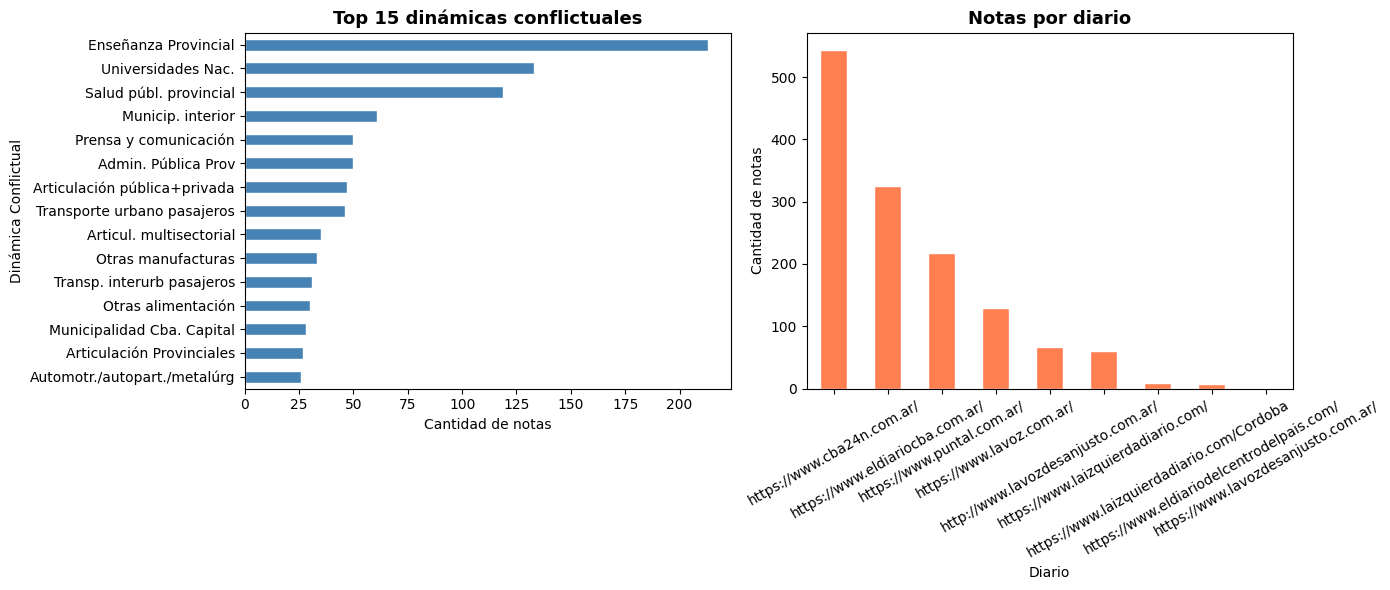

In [ ]:
# ── Gráficos: notas por dinámica y por diario ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

freq_dinamica.head(15).plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top 15 dinámicas conflictuales", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de notas")
axes[0].invert_yaxis()

freq_diario.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Notas por diario", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Cantidad de notas")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

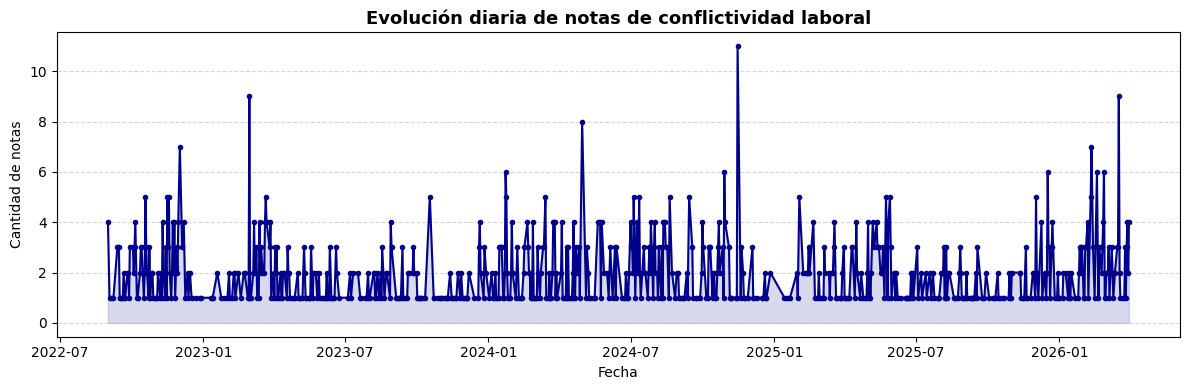

In [ ]:
# ── Serie temporal (línea) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
serie_temporal.plot(ax=ax, marker="o", linewidth=1.5, color="darkblue", markersize=3)
ax.fill_between(serie_temporal.index, serie_temporal.values, alpha=0.15, color="darkblue")
ax.set_title("Evolución diaria de notas de conflictividad laboral", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de notas")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

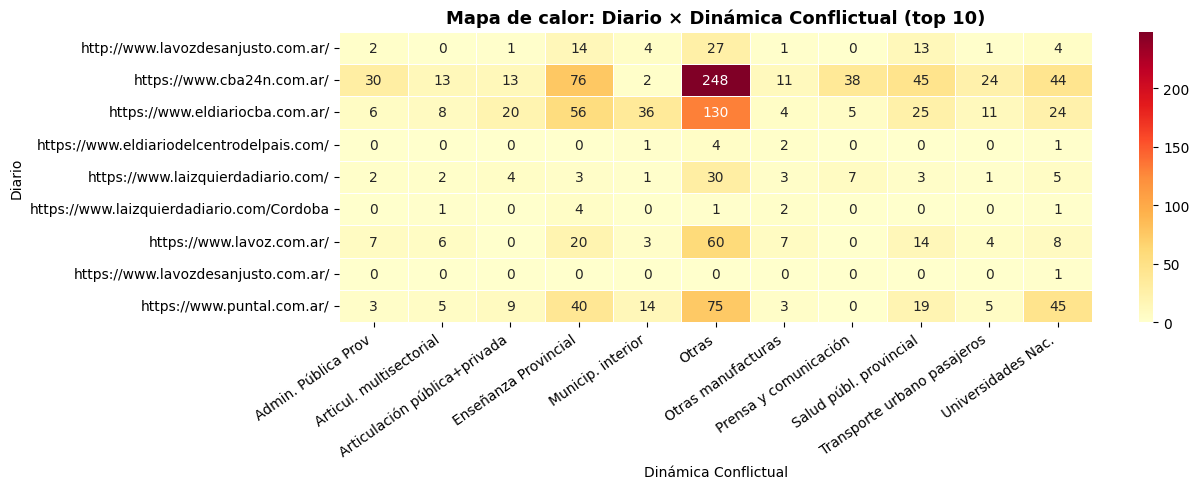

In [ ]:
# ── Heatmap Diario × Dinámica Conflictual ────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(tabla_cruzada, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Mapa de calor: Diario × Dinámica Conflictual (top 10)", fontsize=13, fontweight="bold")
ax.set_xlabel("Dinámica Conflictual")
ax.set_ylabel("Diario")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

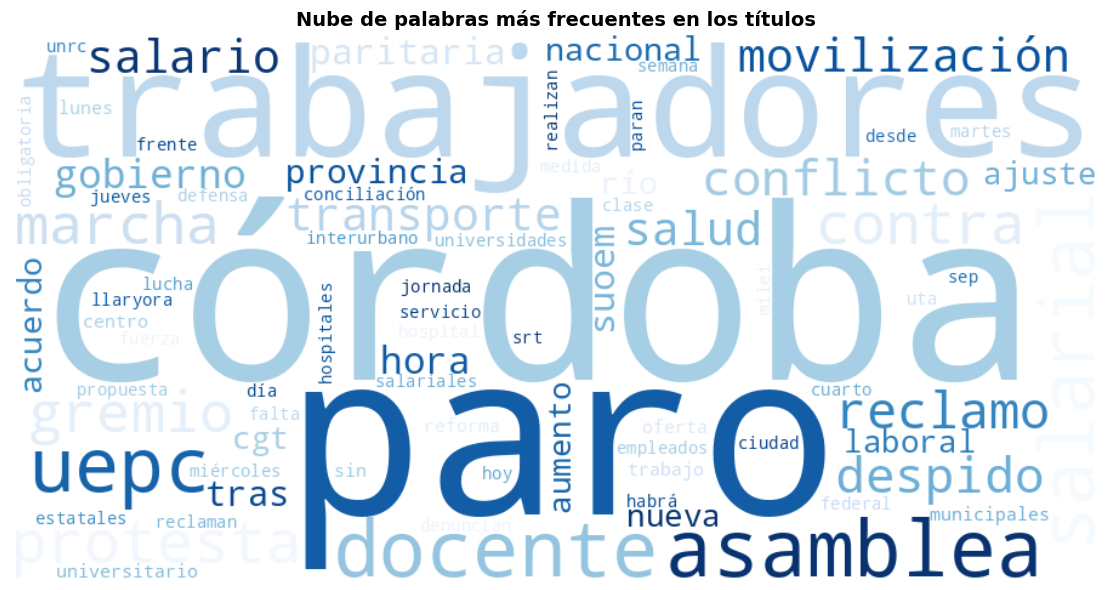

In [ ]:
# ── Nube de palabras (a partir de Título) ────────────────────────
todas_las_palabras = []
for titulo in df_limpio["Título"].dropna():
    todas_las_palabras.extend(tokens(str(titulo)))

texto_nube = " ".join(todas_las_palabras)

nube = WordCloud(
    width=900, height=450, background_color="white",
    colormap="Blues", max_words=80, collocations=False
).generate(texto_nube)

plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras más frecuentes en los títulos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Resumen ejecutivo ─────────────────────────────────────────────
resumen = pd.DataFrame({
    "metrica": [
        "Total de notas", "Diarios presentes", "Dinámicas conflictuales distintas",
        "Departamentos cubiertos", "Rango de fechas", "Dinámica dominante", "Diario más activo",
    ],
    "valor": [
        len(df_limpio), df_limpio["Diario"].nunique(), df_limpio["Dinámica Conflictual"].nunique(),
        df_limpio["Departamento"].nunique(),
        f"{df_limpio['Fecha'].min().date()} → {df_limpio['Fecha'].max().date()}",
        freq_dinamica.idxmax(), freq_diario.idxmax(),
    ]
})

print("══ RESUMEN EJECUTIVO ════════════════════════════")
print(resumen.to_string(index=False))

══ RESUMEN EJECUTIVO ════════════════════════════
                          metrica                      valor
                   Total de notas                       1362
                Diarios presentes                          9
Dinámicas conflictuales distintas                         67
          Departamentos cubiertos                         21
                  Rango de fechas    2022-09-01 → 2026-03-31
               Dinámica dominante       Enseñanza Provincial
                Diario más activo https://www.cba24n.com.ar/


## 4. Análisis avanzados

Evolución temporal, comparación de períodos, detección de picos, evolución de organizaciones
y acciones directas vs. indirectas.

Período cubierto: 2022-09-01 → 2026-03-31
Mes con mayor cobertura: 2023-03 (60 notas)


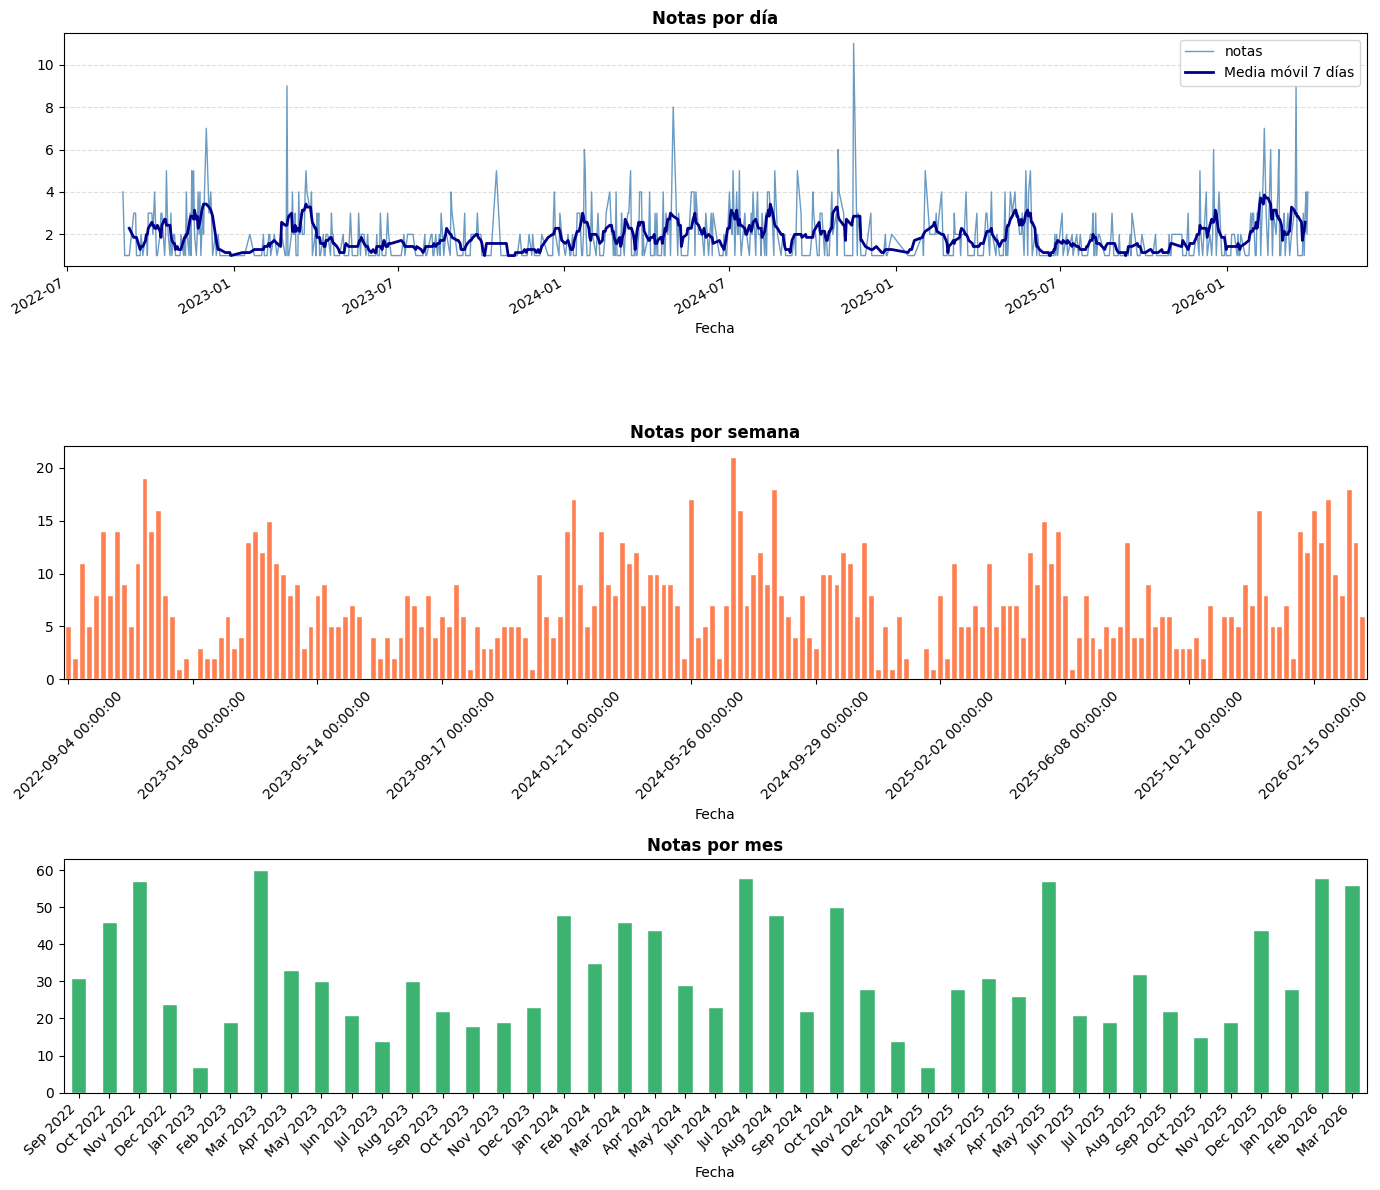

/tmp/ipykernel_2572/3363579866.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([t.strftime("%b %Y") for t in pivot_din.index], rotation=45, ha="right")


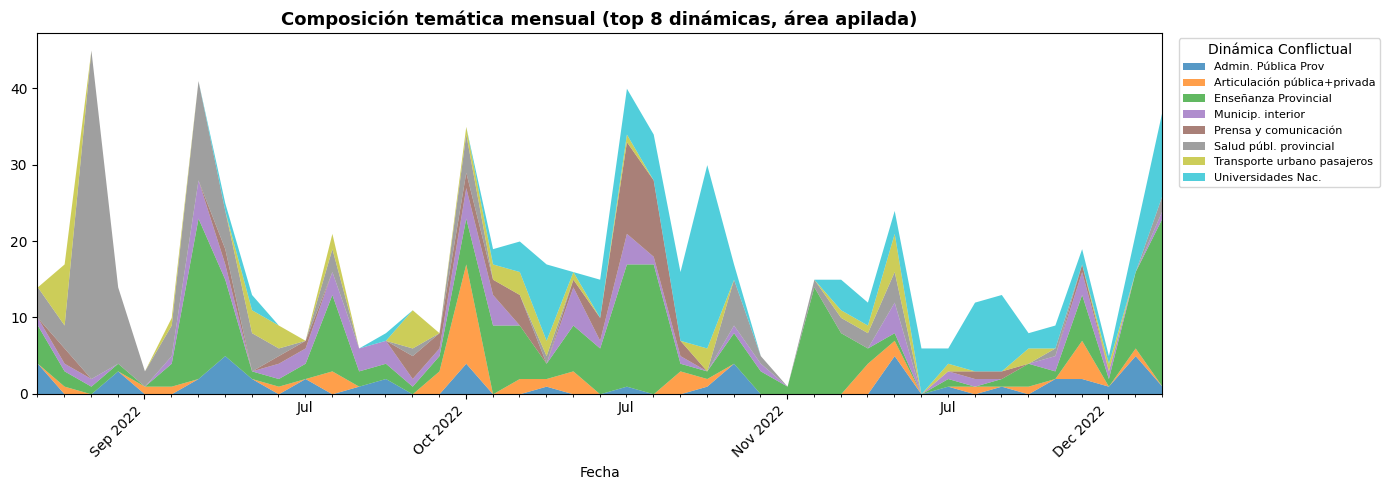

In [ ]:
# ── Notas vs. tiempo (día / semana / mes) ────────────────────────
df_temp = df_limpio.sort_values("Fecha").copy()

serie_diaria  = df_temp.groupby(df_temp["Fecha"].dt.date).size().rename("notas")
serie_diaria.index = pd.to_datetime(serie_diaria.index)
serie_semanal = df_temp.resample("W",  on="Fecha").size().rename("notas")
serie_mensual = df_temp.resample("ME", on="Fecha").size().rename("notas")

print(f"Período cubierto: {serie_diaria.index.min().date()} → {serie_diaria.index.max().date()}")
print(f"Mes con mayor cobertura: {serie_mensual.idxmax().strftime('%Y-%m')} ({serie_mensual.max()} notas)")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

media_movil_7 = serie_diaria.rolling(7, center=True).mean()
serie_diaria.plot(ax=axes[0], color="steelblue", linewidth=1, alpha=0.8)
media_movil_7.plot(ax=axes[0], color="darkblue", linewidth=2, label="Media móvil 7 días")
axes[0].set_title("Notas por día", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

serie_semanal.plot(ax=axes[1], kind="bar", color="coral", edgecolor="white", width=0.85)
axes[1].set_title("Notas por semana", fontsize=12, fontweight="bold")
step = max(1, len(serie_semanal) // 10)
axes[1].set_xticks(axes[1].get_xticks()[::step])
axes[1].tick_params(axis="x", rotation=45)

serie_mensual.plot(ax=axes[2], kind="bar", color="mediumseagreen", edgecolor="white")
axes[2].set_title("Notas por mes", fontsize=12, fontweight="bold")
axes[2].set_xticklabels([idx.strftime("%b %Y") for idx in serie_mensual.index], rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Notas mensuales por Dinámica Conflictual (top 8) — área apilada
top8 = df_temp["Dinámica Conflictual"].value_counts().head(8).index
df_top8 = df_temp[df_temp["Dinámica Conflictual"].isin(top8)]
pivot_din = (
    df_top8.groupby([pd.Grouper(key="Fecha", freq="ME"), "Dinámica Conflictual"])
    .size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
pivot_din.plot(kind="area", stacked=True, ax=ax, colormap="tab10", alpha=0.75, linewidth=0)
ax.set_title("Composición temática mensual (top 8 dinámicas, área apilada)", fontsize=13, fontweight="bold")
ax.set_xticklabels([t.strftime("%b %Y") for t in pivot_din.index], rotation=45, ha="right")
ax.legend(title="Dinámica Conflictual", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

periodo            Antes  Después
total_notas       889.00   472.00
dias_cubiertos    452.00   247.00
diarios_activos     6.00     9.00
dinamicas_unicas   58.00    53.00
notas_por_dia       1.97     1.91


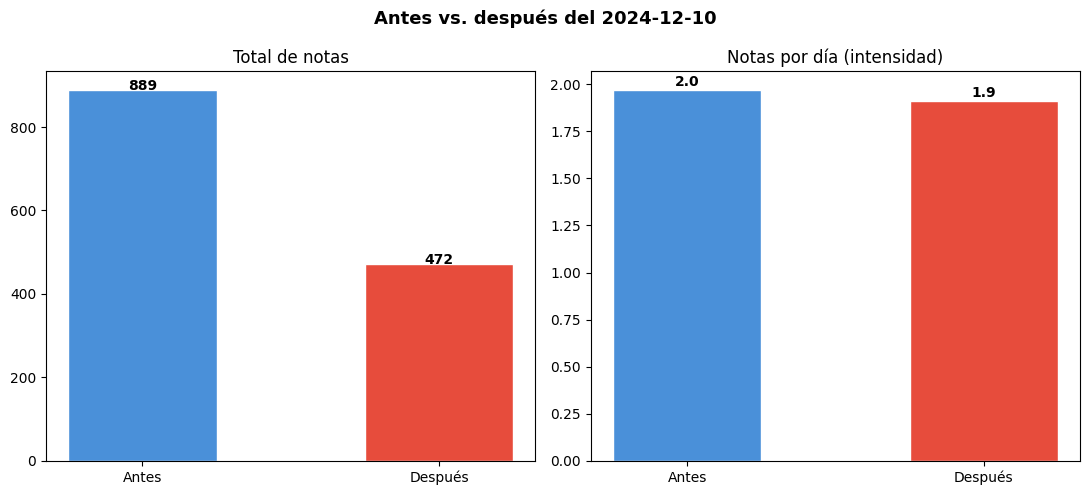

In [ ]:
# ── Comparación entre períodos (antes / después de una fecha) ────
# ┌──────────────────────────────────────────────────────────────┐
FECHA_CORTE = "2024-12-10"   # ajustar según el evento divisor que interese
ETIQUETA_A  = "Antes"
ETIQUETA_B  = "Después"
# └──────────────────────────────────────────────────────────────┘

fecha_corte_dt = pd.to_datetime(FECHA_CORTE)
df_temp["periodo"] = df_temp["Fecha"].apply(lambda f: ETIQUETA_A if f < fecha_corte_dt else ETIQUETA_B)

metricas_periodo = df_temp.groupby("periodo").agg(
    total_notas      = ("Título", "count"),
    dias_cubiertos    = ("Fecha", "nunique"),
    diarios_activos   = ("Diario", "nunique"),
    dinamicas_unicas  = ("Dinámica Conflictual", "nunique"),
).round(2)
metricas_periodo["notas_por_dia"] = (
    metricas_periodo["total_notas"] / metricas_periodo["dias_cubiertos"]
).round(2)
metricas_periodo = metricas_periodo.reindex([ETIQUETA_A, ETIQUETA_B])
print(metricas_periodo.T.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
totales = metricas_periodo["total_notas"]
axes[0].bar(totales.index, totales.values, color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(totales.items()):
    axes[0].text(i, val + 0.5, str(int(val)), ha="center", fontweight="bold")
axes[0].set_title("Total de notas")

x_dia = metricas_periodo["notas_por_dia"]
axes[1].bar(x_dia.index, x_dia.values, color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.5)
for i, (idx, val) in enumerate(x_dia.items()):
    axes[1].text(i, val + 0.02, f"{val:.1f}", ha="center", fontweight="bold")
axes[1].set_title("Notas por día (intensidad)")

plt.suptitle(f"Antes vs. después del {FECHA_CORTE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Media diaria: 1.9 | Umbral de pico: 3.9 notas/día

Picos detectados: 76 días
Fecha
2024-11-15    11
2023-03-01     9
2026-03-18     9
2024-04-30     8
2026-02-11     7
2022-12-02     7
2024-01-23     6
2024-10-29     6
2026-02-27     6
2025-12-17     6
2026-02-18     6
2022-10-19     5
2024-09-14     5
2025-05-24     5
2026-02-10     5
2025-02-02     5
2025-12-02     5
2025-05-29     5
2024-07-05     5
2022-11-18     5
2022-11-16     5
2024-08-20     5
2024-01-24     5
2023-03-22     5
2024-03-14     5
2024-07-12     5
2023-10-18     5
2022-11-10     4
2022-12-07     4
2022-11-30     4
2022-11-23     4
2022-11-25     4
2022-10-06     4
2022-09-01     4
2024-03-24     4
2024-02-27     4
2023-08-29     4
2023-03-28     4
2023-03-23     4
2023-12-21     4
2024-01-31     4
2023-03-21     4
2023-03-14     4
2023-03-07     4
2024-08-12     4
2024-08-01     4
2024-07-27     4
2024-07-09     4
2024-05-25     4
2024-07-01     4
2024-05-22     4
2024-05-23     4
2024-03-26     4
2024-04-04     4

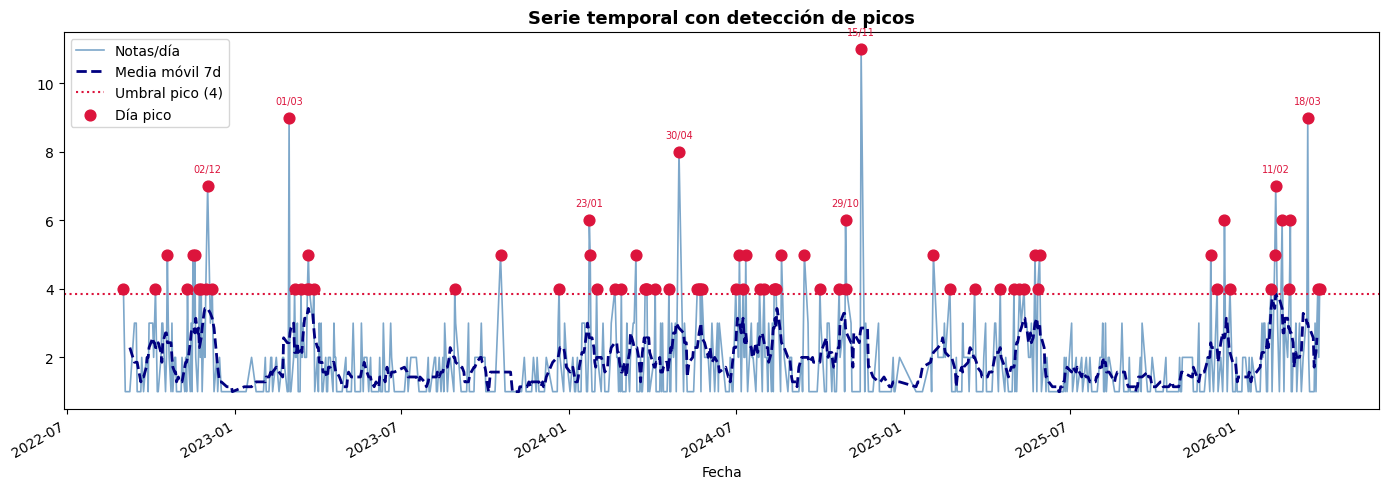

In [ ]:
# ── Detección de picos de conflictividad ──────────────────────────
UMBRAL_SIGMA = 1.5   # Notas > media + N·σ se consideran pico

media_diaria = serie_diaria.mean()
sigma_diaria = serie_diaria.std()
umbral_pico  = media_diaria + UMBRAL_SIGMA * sigma_diaria

print(f"Media diaria: {media_diaria:.1f} | Umbral de pico: {umbral_pico:.1f} notas/día")

dias_pico = serie_diaria[serie_diaria >= umbral_pico].sort_values(ascending=False)
print(f"\nPicos detectados: {len(dias_pico)} días\n{dias_pico.to_string()}")

print("\n── Notas en cada pico (top 5) ──")
for fecha_pico, n in dias_pico.head(5).items():
    notas_pico = df_temp[df_temp["Fecha"].dt.date == fecha_pico.date()][
        ["Diario", "Dinámica Conflictual", "Título"]
    ]
    print(f"\n{fecha_pico.date()} → {int(n)} notas")
    print(f"  Dinámicas: {notas_pico['Dinámica Conflictual'].value_counts().to_dict()}")
    for _, row in notas_pico.head(3).iterrows():
        print(f"    [{row['Diario']}] {str(row['Título'])[:75]}")

fig, ax = plt.subplots(figsize=(14, 5))
serie_diaria.plot(ax=ax, color="steelblue", linewidth=1.2, alpha=0.7, label="Notas/día")
media_movil_7.plot(ax=ax, color="navy", linewidth=2, linestyle="--", label="Media móvil 7d")
ax.axhline(umbral_pico, color="crimson", linewidth=1.5, linestyle=":", label=f"Umbral pico ({umbral_pico:.0f})")
ax.scatter(dias_pico.index, dias_pico.values, color="crimson", zorder=5, s=60, label="Día pico")
for fecha_pico, n in dias_pico.head(8).items():
    ax.annotate(fecha_pico.strftime("%d/%m"), xy=(fecha_pico, n), xytext=(0, 10),
                textcoords="offset points", fontsize=7, color="crimson", ha="center")
ax.set_title("Serie temporal con detección de picos", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2572/51660575.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([t.strftime("%b %Y") for t in evolucion_orgs.index], rotation=45, ha="right")


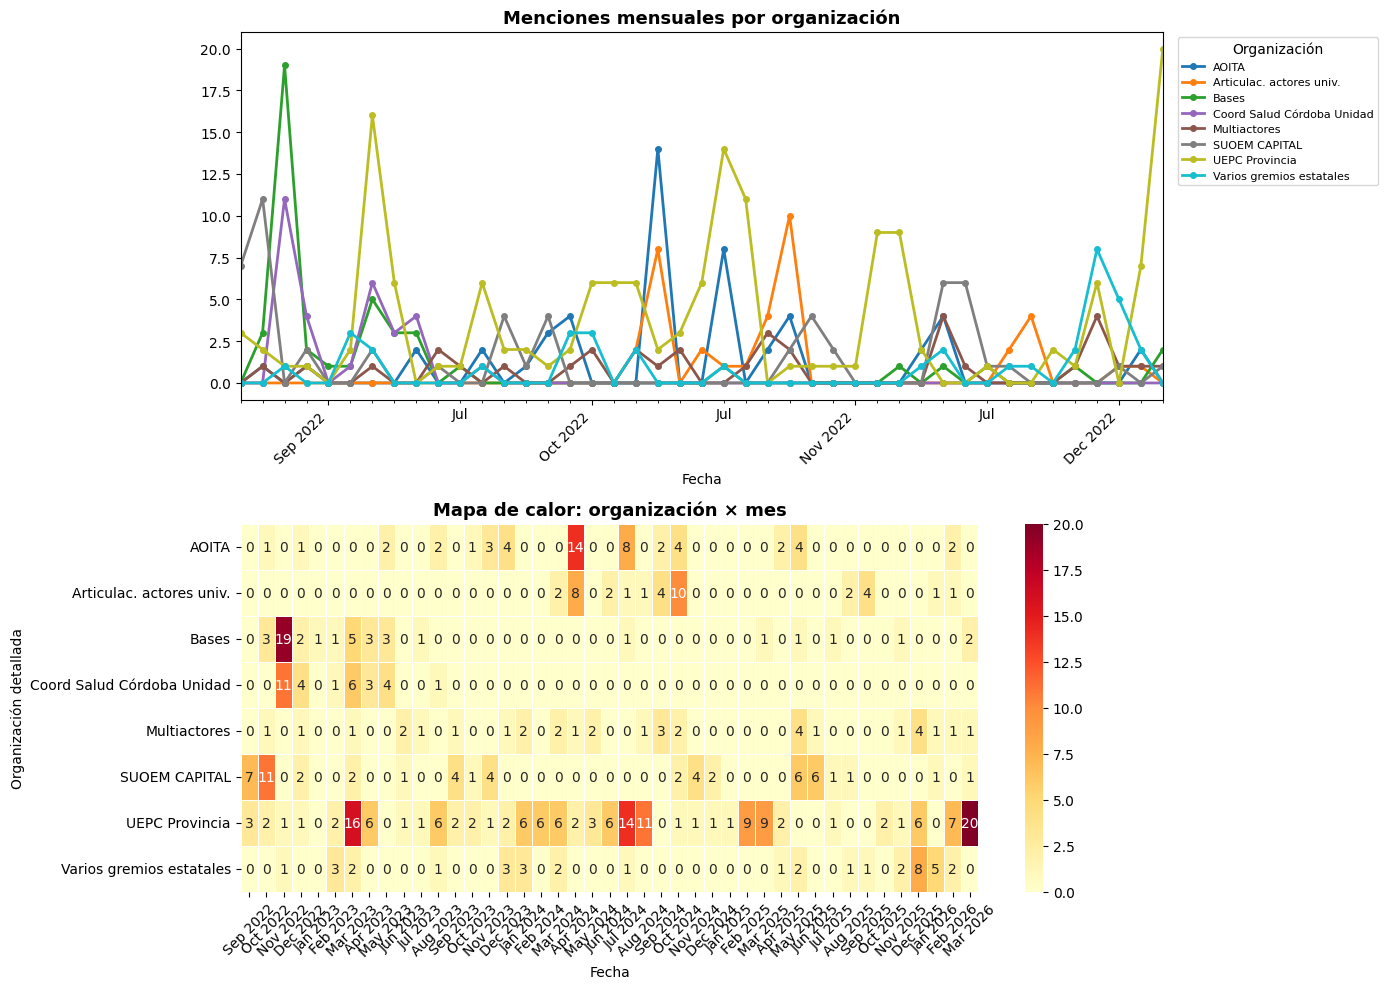


── Pico de visibilidad por organización ──
  UEPC Provincia                      pico: Mar 2026 (20 menciones)
  SUOEM CAPITAL                       pico: Oct 2022 (11 menciones)
  AOITA                               pico: Apr 2024 (14 menciones)
  Bases                               pico: Nov 2022 (19 menciones)
  Varios gremios estatales            pico: Dec 2025 (8 menciones)
  Articulac. actores univ.            pico: Oct 2024 (10 menciones)
  Multiactores                        pico: May 2025 (4 menciones)
  Coord Salud Córdoba Unidad          pico: Nov 2022 (11 menciones)


In [ ]:
# ── Evolución de organizaciones en el tiempo ──────────────────────
N_TOP_ORGS = 8
top_orgs = df_limpio["Organización detallada"].value_counts().head(N_TOP_ORGS).index
df_orgs_tiempo = df_temp[df_temp["Organización detallada"].isin(top_orgs)]

evolucion_orgs = (
    df_orgs_tiempo.groupby([pd.Grouper(key="Fecha", freq="ME"), "Organización detallada"])
    .size().unstack(fill_value=0)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

evolucion_orgs.plot(ax=axes[0], linewidth=2, marker="o", markersize=4, colormap="tab10")
axes[0].set_title("Menciones mensuales por organización", fontsize=13, fontweight="bold")
axes[0].set_xticklabels([t.strftime("%b %Y") for t in evolucion_orgs.index], rotation=45, ha="right")
axes[0].legend(title="Organización", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

sns.heatmap(
    evolucion_orgs.T, ax=axes[1], cmap="YlOrRd", annot=True, fmt="d", linewidths=0.5,
    xticklabels=[t.strftime("%b %Y") for t in evolucion_orgs.index],
)
axes[1].set_title("Mapa de calor: organización × mes", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\n── Pico de visibilidad por organización ──")
for org in top_orgs:
    if org in evolucion_orgs.columns and evolucion_orgs[org].max() > 0:
        mes_pico = evolucion_orgs[org].idxmax()
        print(f"  {org:<35} pico: {mes_pico.strftime('%b %Y')} ({int(evolucion_orgs[org].max())} menciones)")

══ ACCIONES DIRECTAS VS. INDIRECTAS EN EL TIEMPO ══
tipo_accion
Directa      1355
Sin datos       7
Name: count, dtype: int64

  % directa   : 99.5%
  % indirecta : 0.0%


/tmp/ipykernel_2572/827237557.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([t.strftime("%b %Y") for t in tipo_tiempo.index], rotation=45, ha="right")


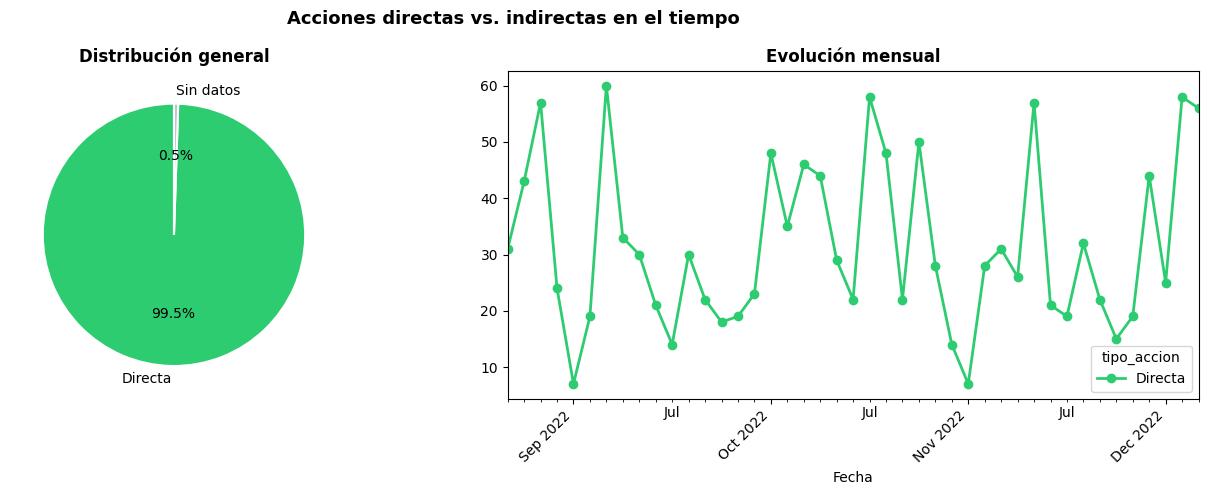

In [ ]:
# ── Acciones directas vs. indirectas en el tiempo ─────────────────
print("══ ACCIONES DIRECTAS VS. INDIRECTAS EN EL TIEMPO ══")

df_temp["tipo_accion"] = df_temp["Formato agregado"].apply(
    lambda f: "Directa" if "directa" in str(f).lower()
    else ("Indirecta" if "indirecta" in str(f).lower() else "Sin datos")
)

distribucion_total = df_temp["tipo_accion"].value_counts()
print(distribucion_total)
print(f"\n  % directa   : {distribucion_total.get('Directa', 0) / len(df_temp) * 100:.1f}%")
print(f"  % indirecta : {distribucion_total.get('Indirecta', 0) / len(df_temp) * 100:.1f}%")

tipo_tiempo = (
    df_temp.groupby([pd.Grouper(key="Fecha", freq="ME"), "tipo_accion"])
    .size().unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLORES_TIPO = {"Directa": "#2ecc71", "Indirecta": "#e74c3c", "Sin datos": "#bdc3c7"}
axes[0].pie(
    distribucion_total.values, labels=distribucion_total.index,
    colors=[COLORES_TIPO.get(t, "gray") for t in distribucion_total.index],
    autopct="%1.1f%%", startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[0].set_title("Distribución general", fontsize=12, fontweight="bold")

cols_disponibles = [c for c in ["Directa", "Indirecta"] if c in tipo_tiempo.columns]
tipo_tiempo[cols_disponibles].plot(
    ax=axes[1], linewidth=2, marker="o", color=[COLORES_TIPO[c] for c in cols_disponibles]
)
axes[1].set_title("Evolución mensual", fontsize=12, fontweight="bold")
axes[1].set_xticklabels([t.strftime("%b %Y") for t in tipo_tiempo.index], rotation=45, ha="right")

plt.suptitle("Acciones directas vs. indirectas en el tiempo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Perfil editorial, actores y diversidad temática

Análisis a nivel diario/organización: qué cubre cada medio, qué actores aparecen más,
y qué tan diversa es la cobertura de cada uno.

══ PERFIL TEMÁTICO POR DIARIO ═══════════════════
Dinámica Conflictual                       Admin. Pública Nac  Admin. Pública Prov  Aeronáuticos-Transp aéreo  Agroindustrias  Artic. Discapacidad  Articul. multisectorial  Articulación Provinciales  Articulación estatal multinivel  Articulación nacionales  Articulación pública+privada  Automotr./autopart./metalúrg  Banca privada y pública  Cadeteria y mensajería-NO USAR  Call Centers  Camioneros  Comercio  Construcción  DDHH  Depend. Munic. Capital  Distrib. agua y gas  EPEC  Economía popular  Empresas Estatales Nac.  Enseñanza Provincial  Entidades deportivas y civiles  Feminismos y diversidades  INTA/ INV/ INASE  Jubiladxs  Juegos y Lotería P  Justicia Nacional  Justicia provincial  Mov culturales y artísticos  Mov. antiracistas y antifascistas  Mov. estudiantil  Municip. interior  Municipalidad Cba. Capital  NO USAR  Organ. Desctraliz/Desconcentr. Nac  Organismos CyT  Organizades inform.por actividad  Otras alimentación  Otras manuf

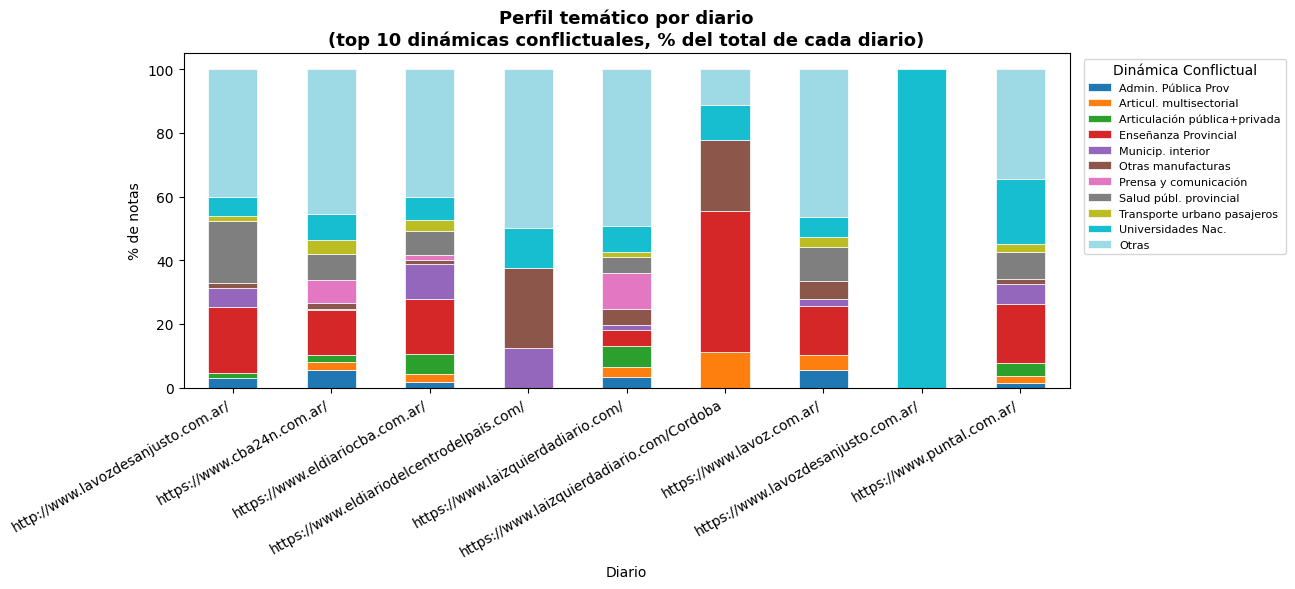


── Dinámica conflictual dominante por diario ──
  http://www.lavozdesanjusto.com.ar/ → Enseñanza Provincial  (20.9%)
  https://www.cba24n.com.ar/     → Enseñanza Provincial  (14.0%)
  https://www.eldiariocba.com.ar/ → Enseñanza Provincial  (17.2%)
  https://www.eldiariodelcentrodelpais.com/ → Sector en torno a personas con discapacidad  (37.5%)
  https://www.laizquierdadiario.com/ → Automotr./autopart./metalúrg  (14.8%)
  https://www.laizquierdadiario.com/Cordoba → Enseñanza Provincial  (44.4%)
  https://www.lavoz.com.ar/      → Enseñanza Provincial  (15.5%)
  https://www.lavozdesanjusto.com.ar/ → Universidades Nac.  (100.0%)
  https://www.puntal.com.ar/     → Universidades Nac.  (20.6%)


In [ ]:
# ── Perfil temático por diario ────────────────────────────────────
print("══ PERFIL TEMÁTICO POR DIARIO ═══════════════════")

perfil = pd.crosstab(df_limpio["Diario"], df_limpio["Dinámica Conflictual"], normalize="index") * 100
print(perfil.round(1).to_string())

N_TOP_DINAMICAS = 10
top_dinamicas_global = df_limpio["Dinámica Conflictual"].value_counts().head(N_TOP_DINAMICAS).index
perfil_plot = perfil[[c for c in perfil.columns if c in top_dinamicas_global]].copy()
perfil_plot["Otras"] = 100 - perfil_plot.sum(axis=1)

perfil_plot.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="tab20", edgecolor="white", linewidth=0.5)
plt.title(f"Perfil temático por diario\n(top {N_TOP_DINAMICAS} dinámicas conflictuales, % del total de cada diario)",
          fontsize=13, fontweight="bold")
plt.xlabel("Diario")
plt.ylabel("% de notas")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Dinámica Conflictual", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

dominante_por_diario = perfil.idxmax(axis=1)
print("\n── Dinámica conflictual dominante por diario ──")
for diario_nombre, dinamica in dominante_por_diario.items():
    pct = perfil.loc[diario_nombre, dinamica]
    print(f"  {diario_nombre:<30} → {dinamica}  ({pct:.1f}%)")

══ RED DE CO-OCURRENCIA DE PALABRAS EN TÍTULOS ══
Nodos (palabras únicas en red): 373
Aristas (pares co-ocurrentes)  : 1316

── Top 10 palabras más centrales en la red ──
  córdoba                   centralidad: 0.460
  paro                      centralidad: 0.419
  trabajadores              centralidad: 0.301
  uepc                      centralidad: 0.159
  salarial                  centralidad: 0.151
  docentes                  centralidad: 0.132
  contra                    centralidad: 0.124
  marcha                    centralidad: 0.116
  asambleas                 centralidad: 0.116
  transporte                centralidad: 0.094


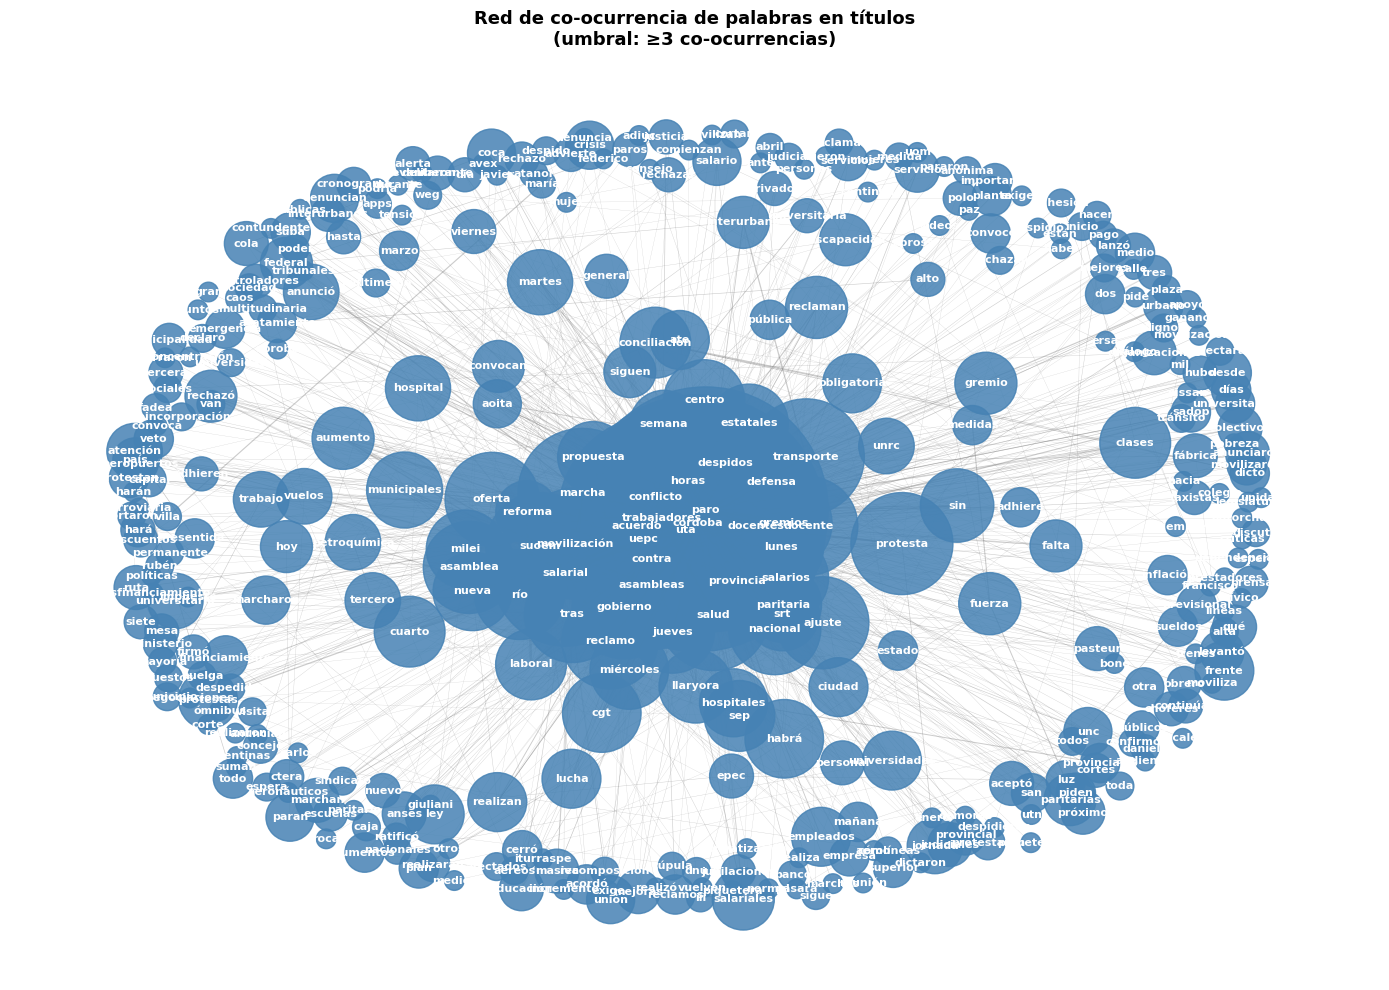

In [ ]:
# ── Red de co-ocurrencia de palabras en títulos ───────────────────
print("══ RED DE CO-OCURRENCIA DE PALABRAS EN TÍTULOS ══")

pares_raw = []
for titulo in df_limpio["Título"].dropna():
    kws = sorted(tokens(str(titulo)))
    if len(kws) > 1:
        pares_raw.extend(itertools.combinations(kws, 2))

conteo_pares = Counter(pares_raw)

UMBRAL_COOCURRENCIA = 3   # subir si el gráfico sale muy denso

G = nx.Graph()
for (p1, p2), peso in conteo_pares.items():
    if peso >= UMBRAL_COOCURRENCIA:
        G.add_edge(p1, p2, weight=peso)

print(f"Nodos (palabras únicas en red): {G.number_of_nodes()}")
print(f"Aristas (pares co-ocurrentes)  : {G.number_of_edges()}")

if G.number_of_nodes() > 0:
    centralidad = nx.degree_centrality(G)
    top_centrales = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\n── Top 10 palabras más centrales en la red ──")
    for palabra, cent in top_centrales:
        print(f"  {palabra:<25} centralidad: {cent:.3f}")

    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=1.5)

    grados = dict(G.degree())
    node_sizes = [grados[n] * 200 for n in G.nodes()]
    pesos_aristas = [G[u][v]["weight"] for u, v in G.edges()]
    max_peso = max(pesos_aristas) if pesos_aristas else 1

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="steelblue", alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, width=[p / max_peso * 4 for p in pesos_aristas],
                            alpha=0.4, edge_color="gray", ax=ax)

    ax.set_title(f"Red de co-ocurrencia de palabras en títulos\n(umbral: ≥{UMBRAL_COOCURRENCIA} co-ocurrencias)",
                 fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No se formaron aristas con el umbral actual. Probá bajar UMBRAL_COOCURRENCIA.")

══ ÍNDICE DE DIVERSIDAD TEMÁTICA (SHANNON) ══════
Entropía máxima posible (con 67 dinámicas conflictuales): 6.07 bits

Diario
https://www.cba24n.com.ar/                   4.847
https://www.eldiariocba.com.ar/              4.677
https://www.lavoz.com.ar/                    4.560
https://www.puntal.com.ar/                   4.204
https://www.laizquierdadiario.com/           4.016
http://www.lavozdesanjusto.com.ar/           3.861
https://www.eldiariodelcentrodelpais.com/    2.156
https://www.laizquierdadiario.com/Cordoba    2.059
https://www.lavozdesanjusto.com.ar/         -0.000

── Interpretación ──
  Más diverso  : https://www.cba24n.com.ar/ (4.85 bits)
  Menos diverso: https://www.lavozdesanjusto.com.ar/ (-0.00 bits)


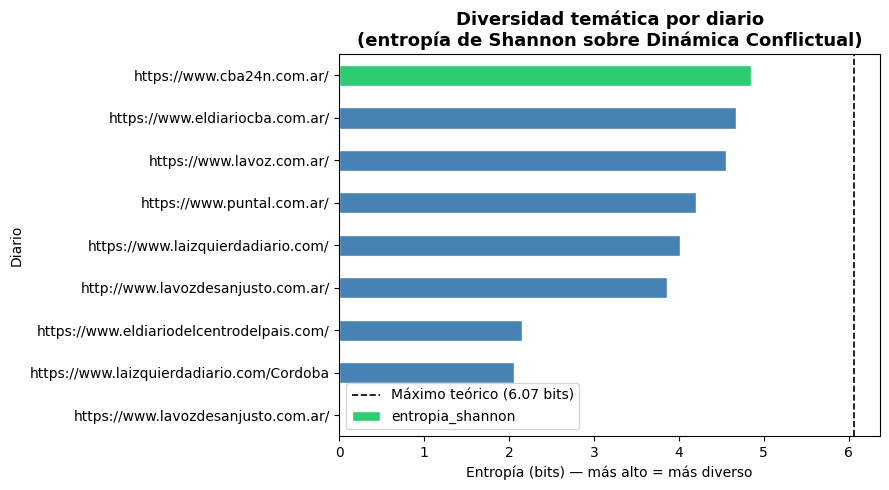

In [ ]:
# ── Diversidad temática por diario (entropía de Shannon) ──────────
print("══ ÍNDICE DE DIVERSIDAD TEMÁTICA (SHANNON) ══════")

def entropia_shannon(serie):
    proporciones = serie / serie.sum()
    proporciones = proporciones[proporciones > 0]
    return -(proporciones * np.log2(proporciones)).sum()

entropia_por_diario = (
    df_limpio.groupby("Diario")["Dinámica Conflictual"]
    .value_counts()
    .unstack(fill_value=0)
    .apply(entropia_shannon, axis=1)
    .rename("entropia_shannon")
    .sort_values(ascending=False)
)

n_dinamicas = df_limpio["Dinámica Conflictual"].nunique()
entropia_max = np.log2(n_dinamicas)

print(f"Entropía máxima posible (con {n_dinamicas} dinámicas conflictuales): {entropia_max:.2f} bits\n")
print(entropia_por_diario.round(3).to_string())
print("\n── Interpretación ──")
print(f"  Más diverso  : {entropia_por_diario.idxmax()} ({entropia_por_diario.max():.2f} bits)")
print(f"  Menos diverso: {entropia_por_diario.idxmin()} ({entropia_por_diario.min():.2f} bits)")

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#2ecc71" if v == entropia_por_diario.max()
           else "#e74c3c" if v == entropia_por_diario.min()
           else "steelblue"
           for v in entropia_por_diario]
entropia_por_diario.plot(kind="barh", ax=ax, color=colores, edgecolor="white")
ax.axvline(x=entropia_max, color="black", linestyle="--", linewidth=1.2,
           label=f"Máximo teórico ({entropia_max:.2f} bits)")
ax.set_title("Diversidad temática por diario\n(entropía de Shannon sobre Dinámica Conflictual)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Entropía (bits) — más alto = más diverso")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

══ ORGANIZACIONES MÁS MENCIONADAS ═══════════════
              organizacion  menciones  n_diarios                                                                                                                                                                                                                                                                          diarios
            UEPC Provincia        161          7                                            http://www.lavozdesanjusto.com.ar/, https://www.eldiariocba.com.ar/, https://www.laizquierdadiario.com/, https://www.cba24n.com.ar/, https://www.puntal.com.ar/, https://www.lavoz.com.ar/, https://www.laizquierdadiario.com/Cordoba
             SUOEM CAPITAL         56          3                                                                                                                                                                                           https://www.cba24n.com.ar/, https://www.lavoz.com.ar/, https://www.eldi

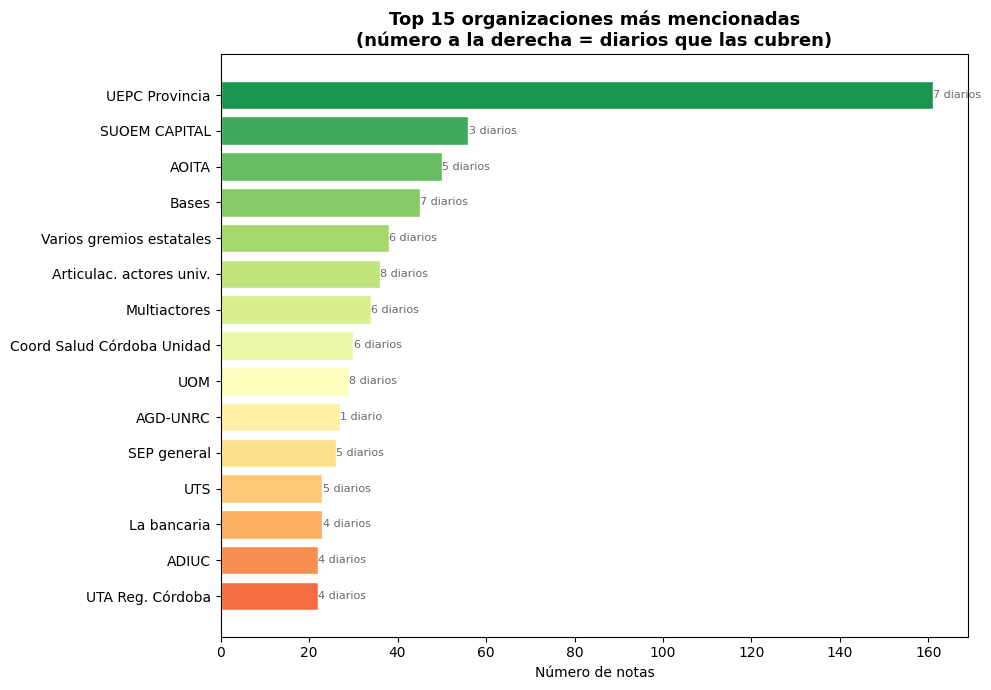

In [ ]:
# ── Organizaciones más mencionadas ────────────────────────────────
print("══ ORGANIZACIONES MÁS MENCIONADAS ═══════════════")

COL_ORG = "Organización detallada"   # cambiar a "Organización Agregada" para el nivel agrupado
N_TOP_ORGS = 15

freq_org = df_limpio[COL_ORG].value_counts().head(N_TOP_ORGS)

filas_org = []
for org in freq_org.index:
    mask = df_limpio[COL_ORG] == org
    diarios_que_lo_cubren = df_limpio[mask]["Diario"].unique().tolist()
    filas_org.append({
        "organizacion": org,
        "menciones": freq_org[org],
        "n_diarios": len(diarios_que_lo_cubren),
        "diarios": ", ".join(diarios_que_lo_cubren),
    })

df_orgs = pd.DataFrame(filas_org)
print(df_orgs.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
colores_org = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_orgs)))
bars = ax.barh(df_orgs["organizacion"], df_orgs["menciones"], color=colores_org[::-1], edgecolor="white")

for bar, n_d in zip(bars, df_orgs["n_diarios"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{n_d} diario{'s' if n_d != 1 else ''}", va="center", fontsize=8, color="dimgray")

ax.set_title(f"Top {N_TOP_ORGS} organizaciones más mencionadas\n(número a la derecha = diarios que las cubren)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Número de notas")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Motor gráfico unificado y parametrizable

Un único motor (`graficar`) para los gráficos de barras/líneas por período, más un
**menú interactivo** (`menu_graficos`) que agrupa TODOS los análisis del notebook —
incluidos los nuevos (perfil editorial, red de co-ocurrencia, diversidad Shannon,
organizaciones, evolución temporal, picos, comparación de períodos, directa vs. indirecta) —
bajo una misma interfaz de parámetros (rango de años, granularidad, top N, tipo de valores).

In [ ]:
# ══════════════════════════════════════════════════════════════
# NUEVO en esta versión (respecto a la anterior):
#
# 1) _mostrar_valores_unicos(): antes de pedirte "valores separados
#    por coma" para un filtro, el programa te MUESTRA los valores
#    reales que existen en esa columna (hasta 40; si hay más, te
#    avisa cuántos hay en total y te muestra los 40 más frecuentes).
#    Así no adivinás cómo está escrito "Público" vs "público" vs
#    "PUBLICO", lo ves tal cual está en los datos.
#
# 2) La opción 19 ahora admite un SEGUNDO filtro opcional (además
#    del primero). Por ejemplo: graficar 'Dinámica Conflictual',
#    filtrando por 'Pertenencia Sectorial' = Público Y ADEMÁS por
#    'Diario' = Clarín, La Nación.
#    Internamente: el primer filtro se aplica al DataFrame ANTES
#    de llamar a graficar(); el segundo filtro se pasa como el
#    filtro propio de graficar() (que sigue aceptando uno solo).
#    El resultado es equivalente a aplicar ambos filtros a la vez.
# ══════════════════════════════════════════════════════════════

TIPOS_GRAFICO_VALIDOS = ['apiladas_vertical', 'apiladas_horizontal', 'lineas', 'perfil_100']


def _pedir_columna_valida(df, mensaje):
    """Pide una columna por input() y reintenta hasta que exista en df.columns.
    Case-insensitive: si el usuario tipea distinto mayúsculas/minúsculas,
    se corrige automáticamente al nombre real de la columna."""
    columnas_lower = {c.lower(): c for c in df.columns}
    while True:
        entrada = input(mensaje).strip()
        if entrada.lower() in columnas_lower:
            return columnas_lower[entrada.lower()]
        print(f"  ✗ '{entrada}' no es una columna válida.")
        print(f"  Columnas disponibles: {list(df.columns)}\n")


def _pedir_opcion_valida(mensaje, opciones_validas):
    """Pide un valor por input() y reintenta hasta que esté dentro de
    opciones_validas (case-insensitive). Devuelve el valor normalizado
    tal como aparece en opciones_validas."""
    opciones_lower = {o.lower(): o for o in opciones_validas}
    while True:
        entrada = input(mensaje).strip()
        if entrada.lower() in opciones_lower:
            return opciones_lower[entrada.lower()]
        print(f"  ✗ '{entrada}' no es válido. Opciones: {opciones_validas}\n")


def _mostrar_valores_unicos(df, columna, max_mostrar=40):
    """Imprime los valores únicos presentes en `columna`, para que el
    usuario sepa exactamente qué escribir en el filtro (respeta mayúsculas,
    tildes, etc. tal como están en los datos)."""
    valores = df[columna].dropna().astype(str).str.strip()
    conteo = valores.value_counts()
    total_unicos = len(conteo)

    print(f"\n  Valores disponibles en '{columna}' ({total_unicos} distintos):")
    if total_unicos <= max_mostrar:
        for v in sorted(conteo.index):
            print(f"    • {v}  ({conteo[v]})")
    else:
        print(f"  (hay {total_unicos} valores distintos; se muestran los {max_mostrar} más frecuentes)")
        for v in conteo.head(max_mostrar).index:
            print(f"    • {v}  ({conteo[v]})")
    print()


def _pedir_filtro(df, etiqueta="filtro"):
    """Pide columna, modo (incluir/excluir) y valores para un filtro,
    mostrando primero los valores disponibles de esa columna.
    Devuelve (col_filtro, modo_filtro, valores_filtro) o (None, 'excluir', None)
    si el usuario no ingresa valores."""
    col_filtro = _pedir_columna_valida(df, f"Columna del {etiqueta}: ")
    _mostrar_valores_unicos(df, col_filtro)
    modo_filtro = _pedir_opcion_valida("Modo (incluir/excluir): ", ['incluir', 'excluir'])
    valores_filtro = [
        v.strip() for v in input("Valores (separados por coma, copiá los nombres de arriba): ").split(',')
        if v.strip()
    ]
    if not valores_filtro:
        print(f"  ⚠ No ingresaste valores para el {etiqueta}; se ignora.")
        return None, 'excluir', None
    return col_filtro, modo_filtro, valores_filtro


def _aplicar_filtro(df, col_filtro, modo, valores):
    """modo: 'excluir' o 'incluir'. valores: lista de strings (case-insensitive)."""
    if col_filtro is None or not valores:
        return df
    serie = df[col_filtro].astype(str).str.strip().str.lower()
    valores_low = [v.strip().lower() for v in valores]
    if modo == 'incluir':
        mask = serie.isin(valores_low)
    else:
        mask = ~serie.isin(valores_low)
    return df[mask]


def graficar(
    df_limpio: pd.DataFrame,
    col_categoria: str,
    titulo: str,
    tipo_grafico: str = 'apiladas_vertical',   # 'apiladas_vertical' | 'apiladas_horizontal' | 'lineas' | 'perfil_100'
    col_filtro: str = None,
    modo_filtro: str = 'excluir',
    valores_filtro: list = None,
    granularidad: str = 'año',                 # 'año' | 'trimestre' | 'mes'
    año_inicio: int = 2022,
    año_fin: int = 2026,
    n_top: int = None,
    categorias_fijas: list = None,
    tipo_valores: str = 'absoluto',             # 'absoluto' o 'porcentaje'
):
    # ── Validaciones tempranas (fail fast, con mensaje claro) ──
    if col_categoria not in df_limpio.columns:
        raise ValueError(
            f"'{col_categoria}' no es una columna válida de df_limpio. "
            f"Columnas disponibles: {list(df_limpio.columns)}"
        )
    if tipo_grafico not in TIPOS_GRAFICO_VALIDOS:
        raise ValueError(
            f"tipo_grafico='{tipo_grafico}' no es válido. "
            f"Opciones válidas: {TIPOS_GRAFICO_VALIDOS}"
        )
    if col_filtro is not None and col_filtro not in df_limpio.columns:
        raise ValueError(
            f"col_filtro='{col_filtro}' no es una columna válida de df_limpio. "
            f"Columnas disponibles: {list(df_limpio.columns)}"
        )
    # ─────────────────────────────────────────────────────────

    df_work = df_limpio.copy()
    df_work = _aplicar_filtro(df_work, col_filtro, modo_filtro, valores_filtro)
    df_work = df_work[(df_work['Año'] >= año_inicio) & (df_work['Año'] <= año_fin)].copy()

    if df_work.empty:
        print(f"⚠ Sin registros para '{titulo}' en el rango {año_inicio}-{año_fin} con los filtros aplicados.")
        return None

    if granularidad == 'año':
        df_work['periodo'] = df_work['Año'].astype('Int64').astype(str)
    elif granularidad == 'trimestre':
        df_work['periodo'] = df_work['Fecha'].dt.to_period('Q').astype(str)
    else:
        df_work['periodo'] = df_work['Fecha'].dt.to_period('M').astype(str)

    if categorias_fijas:
        categorias = [c for c in categorias_fijas if c in df_work[col_categoria].unique()]
        df_work = df_work[df_work[col_categoria].isin(categorias)]
    elif n_top:
        categorias = df_work[col_categoria].value_counts().head(n_top).index
        df_work = df_work[df_work[col_categoria].isin(categorias)]

    tabla = df_work.pivot_table(
        index='periodo', columns=col_categoria, values='Título', aggfunc='count', fill_value=0
    ).sort_index()

    if tipo_valores == 'porcentaje' or tipo_grafico == 'perfil_100':
        tabla_plot = tabla.div(tabla.sum(axis=1), axis=0) * 100
        ylabel = 'Porcentaje (%)'
    else:
        tabla_plot = tabla
        ylabel = 'Cantidad (valores absolutos)'

    n_periodos = len(tabla_plot)
    ancho = max(9, min(18, n_periodos * 1.3))
    fig, ax = plt.subplots(figsize=(ancho, 7))

    if tipo_grafico in ('apiladas_vertical', 'perfil_100'):
        tabla_plot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
        ax.set_xlabel(granularidad.capitalize())
        ax.set_ylabel(ylabel)
        rot = 0 if granularidad == 'año' else 45
        plt.xticks(rotation=rot, ha='right' if rot else 'center')
        ax.legend(title=col_categoria, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    elif tipo_grafico == 'apiladas_horizontal':
        tabla_plot.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
        ax.set_ylabel(granularidad.capitalize())
        ax.set_xlabel(ylabel)
        ax.legend(title=col_categoria, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    elif tipo_grafico == 'lineas':
        tabla_plot.plot(kind='line', ax=ax, marker='o', linewidth=2)
        ax.set_xlabel(granularidad.capitalize())
        ax.set_ylabel(ylabel)
        rot = 0 if granularidad == 'año' else 45
        plt.xticks(rotation=rot, ha='right' if rot else 'center')
        ax.legend(title=col_categoria, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

    return tabla_plot


# ══════════════════════════════════════════════════════════════
# FUNCIONES DE LOS ANÁLISIS "NO REDUCIBLES" A pivot+plot
# ══════════════════════════════════════════════════════════════

def analisis_red_coocurrencia(df_limpio, año_inicio=2022, año_fin=2026, umbral=3):
    df_periodo = df_limpio[(df_limpio['Año'] >= año_inicio) & (df_limpio['Año'] <= año_fin)]
    pares_raw = []
    for titulo in df_periodo["Título"].dropna():
        kws = sorted(tokens(str(titulo)))
        if len(kws) > 1:
            pares_raw.extend(itertools.combinations(kws, 2))
    conteo_pares = Counter(pares_raw)

    G = nx.Graph()
    for (p1, p2), peso in conteo_pares.items():
        if peso >= umbral:
            G.add_edge(p1, p2, weight=peso)

    print(f"Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}")
    if G.number_of_nodes() == 0:
        print("⚠ Sin aristas con ese umbral. Probá bajarlo.")
        return None

    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=1.5)
    grados = dict(G.degree())
    node_sizes = [grados[n] * 200 for n in G.nodes()]
    pesos_aristas = [G[u][v]["weight"] for u, v in G.edges()]
    max_peso = max(pesos_aristas) if pesos_aristas else 1
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="steelblue", alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, width=[p / max_peso * 4 for p in pesos_aristas], alpha=0.4, edge_color="gray", ax=ax)
    ax.set_title(f"Red de co-ocurrencia ({año_inicio}-{año_fin}, umbral≥{umbral})", fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    return G


def analisis_diversidad_shannon(df_limpio, año_inicio=2022, año_fin=2026):
    df_periodo = df_limpio[(df_limpio['Año'] >= año_inicio) & (df_limpio['Año'] <= año_fin)]

    def entropia_shannon(serie):
        p = serie / serie.sum()
        p = p[p > 0]
        return -(p * np.log2(p)).sum()

    entropia_por_diario = (
        df_periodo.groupby("Diario")["Dinámica Conflictual"]
        .value_counts().unstack(fill_value=0)
        .apply(entropia_shannon, axis=1).rename("entropia_shannon").sort_values(ascending=False)
    )
    n_dinamicas = df_periodo["Dinámica Conflictual"].nunique()
    entropia_max = np.log2(n_dinamicas) if n_dinamicas > 0 else 0
    print(entropia_por_diario.round(3).to_string())

    fig, ax = plt.subplots(figsize=(9, 5))
    colores = ["#2ecc71" if v == entropia_por_diario.max() else
               "#e74c3c" if v == entropia_por_diario.min() else "steelblue"
               for v in entropia_por_diario]
    entropia_por_diario.plot(kind="barh", ax=ax, color=colores, edgecolor="white")
    ax.axvline(x=entropia_max, color="black", linestyle="--", label=f"Máximo teórico ({entropia_max:.2f})")
    ax.set_title(f"Diversidad temática por diario ({año_inicio}-{año_fin})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Entropía (bits)")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return entropia_por_diario


def analisis_organizaciones(df_limpio, año_inicio=2022, año_fin=2026, col_org="Organización detallada", n_top=15):
    df_periodo = df_limpio[(df_limpio['Año'] >= año_inicio) & (df_limpio['Año'] <= año_fin)]
    freq_org = df_periodo[col_org].value_counts().head(n_top)

    filas = []
    for org in freq_org.index:
        diarios = df_periodo[df_periodo[col_org] == org]["Diario"].unique().tolist()
        filas.append({"organizacion": org, "menciones": freq_org[org], "n_diarios": len(diarios)})
    df_orgs = pd.DataFrame(filas)
    print(df_orgs.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 7))
    colores = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_orgs)))
    ax.barh(df_orgs["organizacion"], df_orgs["menciones"], color=colores[::-1], edgecolor="white")
    ax.set_title(f"Top {n_top} organizaciones ({año_inicio}-{año_fin})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Número de notas")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return df_orgs


def analisis_evolucion_organizaciones(df_limpio, año_inicio=2022, año_fin=2026, n_top=8):
    df_periodo = df_limpio[(df_limpio['Año'] >= año_inicio) & (df_limpio['Año'] <= año_fin)].copy()
    top_orgs = df_periodo["Organización detallada"].value_counts().head(n_top).index
    df_o = df_periodo[df_periodo["Organización detallada"].isin(top_orgs)]
    evolucion = (
        df_o.groupby([pd.Grouper(key="Fecha", freq="ME"), "Organización detallada"])
        .size().unstack(fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    evolucion.plot(ax=ax, linewidth=2, marker="o", markersize=4, colormap="tab10")
    ax.set_title(f"Evolución mensual de organizaciones ({año_inicio}-{año_fin})", fontsize=13, fontweight="bold")
    ax.legend(title="Organización", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return evolucion


def analisis_picos(df_limpio, año_inicio=2022, año_fin=2026, umbral_sigma=1.5):
    df_periodo = df_limpio[(df_limpio['Año'] >= año_inicio) & (df_limpio['Año'] <= año_fin)].copy()
    serie = df_periodo.groupby(df_periodo["Fecha"].dt.date).size().rename("notas")
    serie.index = pd.to_datetime(serie.index)
    media, sigma = serie.mean(), serie.std()
    umbral = media + umbral_sigma * sigma
    picos = serie[serie >= umbral].sort_values(ascending=False)
    print(f"Media: {media:.1f} | Umbral: {umbral:.1f} | Picos detectados: {len(picos)}")
    print(picos.to_string())

    fig, ax = plt.subplots(figsize=(14, 5))
    serie.plot(ax=ax, color="steelblue", linewidth=1, alpha=0.7, label="Notas/día")
    ax.axhline(umbral, color="crimson", linestyle=":", label=f"Umbral ({umbral:.0f})")
    ax.scatter(picos.index, picos.values, color="crimson", zorder=5, s=50, label="Pico")
    ax.set_title(f"Picos de conflictividad ({año_inicio}-{año_fin})", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return picos


def analisis_comparacion_periodos(df_limpio, fecha_corte, etiqueta_a="Antes", etiqueta_b="Después"):
    df_c = df_limpio.copy()
    fecha_corte_dt = pd.to_datetime(fecha_corte)
    df_c["periodo"] = df_c["Fecha"].apply(lambda f: etiqueta_a if f < fecha_corte_dt else etiqueta_b)

    metricas = df_c.groupby("periodo").agg(
        total_notas=("Título", "count"),
        dias_cubiertos=("Fecha", "nunique"),
        diarios_activos=("Diario", "nunique"),
    ).round(2)
    metricas["notas_por_dia"] = (metricas["total_notas"] / metricas["dias_cubiertos"]).round(2)
    metricas = metricas.reindex([etiqueta_a, etiqueta_b])
    print(metricas.T.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    totales = metricas["total_notas"]
    axes[0].bar(totales.index, totales.values, color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.5)
    axes[0].set_title("Total de notas")
    x_dia = metricas["notas_por_dia"]
    axes[1].bar(x_dia.index, x_dia.values, color=["#4a90d9", "#e74c3c"], edgecolor="white", width=0.5)
    axes[1].set_title("Notas por día (intensidad)")
    plt.suptitle(f"Antes vs. después del {fecha_corte}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return metricas


def analisis_directa_vs_indirecta(df_limpio, año_inicio=2022, año_fin=2026, granularidad="mes"):
    df_periodo = df_limpio[(df_limpio['Año'] >= año_inicio) & (df_limpio['Año'] <= año_fin)].copy()
    df_periodo["tipo_accion"] = df_periodo["Formato agregado"].apply(
        lambda f: "Directa" if "directa" in str(f).lower()
        else ("Indirecta" if "indirecta" in str(f).lower() else "Sin datos")
    )
    freq_col = "ME" if granularidad == "mes" else ("Q" if granularidad == "trimestre" else "YE")
    tipo_tiempo = (
        df_periodo.groupby([pd.Grouper(key="Fecha", freq=freq_col), "tipo_accion"])
        .size().unstack(fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(13, 5))
    COLORES_TIPO = {"Directa": "#2ecc71", "Indirecta": "#e74c3c", "Sin datos": "#bdc3c7"}
    cols_disp = [c for c in ["Directa", "Indirecta"] if c in tipo_tiempo.columns]
    tipo_tiempo[cols_disp].plot(ax=ax, linewidth=2, marker="o", color=[COLORES_TIPO[c] for c in cols_disp])
    ax.set_title(f"Directa vs. indirecta por {granularidad} ({año_inicio}-{año_fin})", fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return tipo_tiempo


# ══════════════════════════════════════════════════════════════
# MENÚ INTERACTIVO — un único punto de entrada a TODOS los análisis
# ══════════════════════════════════════════════════════════════

def menu_graficos(df_limpio: pd.DataFrame):

    print("═" * 62)
    print("  ANÁLISIS Y GRÁFICOS DISPONIBLES")
    print("═" * 62)
    print(" 1  = Conflictos laborales según formato agregado (apiladas)")
    print(" 2  = Acciones directas según tipo de formato de protesta (líneas)")
    print(" 3  = Acciones directas según pertenencia sectorial (líneas)")
    print(" 4  = Demandas — todos los sectores (líneas)")
    print(" 5  = Demandas — sector público (líneas)")
    print(" 6  = Demandas — sectores no públicos (líneas)")
    print(" 7  = Participación de trabajadorxs — total (barras horiz. apiladas)")
    print(" 8  = Participación — sector público (barras horiz. apiladas)")
    print(" 9  = Participación — sectores no públicos (barras horiz. apiladas)")
    print("10  = Top dinámicas conflictuales por período (barras horiz. apiladas)")
    print("11  = Perfil temático por diario (barras apiladas al 100%)")
    print("12  = Red de co-ocurrencia de palabras en títulos")
    print("13  = Diversidad temática por diario (entropía de Shannon)")
    print("14  = Organizaciones más mencionadas")
    print("15  = Evolución mensual de organizaciones")
    print("16  = Detección de picos de conflictividad")
    print("17  = Comparación entre períodos (antes/después de una fecha)")
    print("18  = Acciones directas vs. indirectas en el tiempo")
    print("19  = Gráfico personalizado (elegís vos la columna y el tipo)")
    opcion = input("\nElegí una opción (1-19): ").strip()

    # ── Inputs comunes de período ──────────────────────────────
    print("\n¿Qué granularidad temporal querés usar? (no aplica a todas las opciones)")
    print("  1 = Anual   2 = Trimestral   3 = Mensual")
    g = input("Ingresá 1, 2 o 3 (default 1): ").strip() or '1'
    granularidad = {'1': 'año', '2': 'trimestre', '3': 'mes'}.get(g, 'año')

    año_inicio = int(input("Año de inicio (ej. 2022): ").strip() or 2022)
    año_fin    = int(input("Año de fin (ej. 2026): ").strip() or 2026)

    tipo_valores = 'absoluto'
    if opcion in ['1', '10']:
        t = input("¿Valores absolutos o porcentaje? (a/p, default a): ").strip().lower()
        tipo_valores = 'porcentaje' if t == 'p' else 'absoluto'

    if opcion == '1':
        df_ie = _aplicar_filtro(df_limpio, 'Iniciativa Estado', 'excluir', ['ninguna'])
        return graficar(
            df_ie, col_categoria='Formato agregado',
            titulo=f'Conflictos laborales según formato por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='apiladas_vertical',
            col_filtro='Formato agregado', modo_filtro='excluir', valores_filtro=['vacía', 'vacio', ''],
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin, tipo_valores=tipo_valores,
        )

    elif opcion == '2':
        return graficar(
            df_limpio, col_categoria='Tipo Formato AC',
            titulo=f'Acciones directas según formato de protesta por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='lineas',
            col_filtro='Formato agregado', modo_filtro='incluir', valores_filtro=['directa no paro', 'directa paro'],
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '3':
        return graficar(
            df_limpio, col_categoria='Pertenencia Sectorial',
            titulo=f'Acciones directas según pertenencia sectorial por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='lineas',
            col_filtro='Formato agregado', modo_filtro='incluir', valores_filtro=['directa no paro', 'directa paro'],
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '4':
        return graficar(
            df_limpio, col_categoria='Demanda principal agrupada',
            titulo=f'Demandas — todos los sectores por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='lineas',
            col_filtro='Demanda principal agrupada', modo_filtro='excluir', valores_filtro=['otros'],
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '5':
        df_pub = _aplicar_filtro(df_limpio, 'Pertenencia Sectorial', 'incluir', ['Público'])
        return graficar(
            df_pub, col_categoria='Demanda principal agrupada',
            titulo=f'Demandas — sector público por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='lineas',
            col_filtro='Demanda principal agrupada', modo_filtro='excluir', valores_filtro=['otros'],
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '6':
        df_nopub = _aplicar_filtro(df_limpio, 'Pertenencia Sectorial', 'excluir', ['Público'])
        return graficar(
            df_nopub, col_categoria='Demanda principal agrupada',
            titulo=f'Demandas — sectores no públicos por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='lineas',
            col_filtro='Demanda principal agrupada', modo_filtro='excluir', valores_filtro=['otros'],
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '7':
        return graficar(
            df_limpio, col_categoria='Participación',
            titulo=f'Participación de trabajadorxs por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='apiladas_horizontal',
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '8':
        df_pub = _aplicar_filtro(df_limpio, 'Pertenencia Sectorial', 'incluir', ['Público'])
        return graficar(
            df_pub, col_categoria='Participación',
            titulo=f'Participación — sector público por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='apiladas_horizontal',
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '9':
        df_nopub = _aplicar_filtro(df_limpio, 'Pertenencia Sectorial', 'excluir', ['Público'])
        return graficar(
            df_nopub, col_categoria='Participación',
            titulo=f'Participación — sectores no públicos por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='apiladas_horizontal',
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
        )

    elif opcion == '10':
        n_top_input = input("¿Cuántas dinámicas conflictuales mostrar? (default 10): ").strip()
        n_top = int(n_top_input) if n_top_input else 10
        return graficar(
            df_limpio, col_categoria='Dinámica Conflictual',
            titulo=f'Dinámicas conflictuales con mayor actividad por {granularidad} ({año_inicio}-{año_fin})',
            tipo_grafico='apiladas_horizontal',
            granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
            n_top=n_top, tipo_valores=tipo_valores,
        )

    elif opcion == '11':
        n_top_input = input("¿Cuántas dinámicas mostrar? (default 10, el resto se agrupa en 'Otras'): ").strip()
        n_top = int(n_top_input) if n_top_input else 10
        return graficar(
            df_limpio, col_categoria='Dinámica Conflictual',
            titulo=f'Perfil temático por diario ({año_inicio}-{año_fin})',
            tipo_grafico='perfil_100',
            granularidad='año', año_inicio=año_inicio, año_fin=año_fin, n_top=n_top,
        )
        # Nota: para perfil por Diario en vez de por período, usar directamente
        # la celda de la Sección 5 ("Perfil temático por diario").

    elif opcion == '12':
        umbral_input = input("Umbral de co-ocurrencia (default 3): ").strip()
        umbral = int(umbral_input) if umbral_input else 3
        return analisis_red_coocurrencia(df_limpio, año_inicio, año_fin, umbral)

    elif opcion == '13':
        return analisis_diversidad_shannon(df_limpio, año_inicio, año_fin)

    elif opcion == '14':
        col_org = input("Columna de organización ('Organización detallada' / 'Organización Agregada', default detallada): ").strip()
        col_org = col_org if col_org else "Organización detallada"
        n_top_input = input("Top N organizaciones (default 15): ").strip()
        n_top = int(n_top_input) if n_top_input else 15
        return analisis_organizaciones(df_limpio, año_inicio, año_fin, col_org, n_top)

    elif opcion == '15':
        n_top_input = input("Top N organizaciones (default 8): ").strip()
        n_top = int(n_top_input) if n_top_input else 8
        return analisis_evolucion_organizaciones(df_limpio, año_inicio, año_fin, n_top)

    elif opcion == '16':
        sigma_input = input("Umbral en desvíos estándar (default 1.5): ").strip()
        sigma = float(sigma_input) if sigma_input else 1.5
        return analisis_picos(df_limpio, año_inicio, año_fin, sigma)

    elif opcion == '17':
        fecha_corte = input("Fecha de corte (YYYY-MM-DD): ").strip()
        etiqueta_a = input("Etiqueta período anterior (default 'Antes'): ").strip() or "Antes"
        etiqueta_b = input("Etiqueta período posterior (default 'Después'): ").strip() or "Después"
        return analisis_comparacion_periodos(df_limpio, fecha_corte, etiqueta_a, etiqueta_b)

    elif opcion == '18':
        return analisis_directa_vs_indirecta(df_limpio, año_inicio, año_fin, granularidad)

    elif opcion == '19':
        print("\nColumnas disponibles:", list(df_limpio.columns))

        col_categoria = _pedir_columna_valida(df_limpio, "Columna a graficar (categoría): ")
        tipo_grafico = _pedir_opcion_valida(
            f"Tipo de gráfico {TIPOS_GRAFICO_VALIDOS}: ", TIPOS_GRAFICO_VALIDOS
        )

        # ── Primer filtro (opcional) ────────────────────────────
        df_para_graficar = df_limpio
        usar_filtro1 = _pedir_opcion_valida("¿Aplicar un filtro? (s/n): ", ['s', 'n'])
        if usar_filtro1 == 's':
            col_f1, modo_f1, valores_f1 = _pedir_filtro(df_limpio, etiqueta="primer filtro")
            if col_f1 is not None:
                df_para_graficar = _aplicar_filtro(df_limpio, col_f1, modo_f1, valores_f1)

        # ── Segundo filtro (opcional) ───────────────────────────
        col_filtro2, modo_filtro2, valores_filtro2 = None, 'excluir', None
        usar_filtro2 = _pedir_opcion_valida("¿Aplicar un segundo filtro? (s/n): ", ['s', 'n'])
        if usar_filtro2 == 's':
            col_filtro2, modo_filtro2, valores_filtro2 = _pedir_filtro(
                df_para_graficar, etiqueta="segundo filtro"
            )

        n_top_input = input("Top N categorías (Enter = todas): ").strip()
        try:
            n_top = int(n_top_input) if n_top_input else None
        except ValueError:
            print("  ⚠ Valor no numérico para Top N, se ignora (se muestran todas las categorías).")
            n_top = None

        try:
            return graficar(
                df_para_graficar, col_categoria=col_categoria,
                titulo=f'{col_categoria} por {granularidad} ({año_inicio}-{año_fin})',
                tipo_grafico=tipo_grafico,
                col_filtro=col_filtro2, modo_filtro=modo_filtro2, valores_filtro=valores_filtro2,
                granularidad=granularidad, año_inicio=año_inicio, año_fin=año_fin,
                n_top=n_top, tipo_valores=tipo_valores,
            )
        except ValueError as e:
            print(f"\n✗ Error al generar el gráfico: {e}")
            return None
        except KeyError as e:
            print(f"\n✗ No se encontró la columna o valor {e} en los datos. Revisá el nombre exacto.")
            return None
        except Exception as e:
            print(f"\n✗ Ocurrió un error inesperado ({type(e).__name__}): {e}")
            return None

    else:
        print("Opción inválida.")
        return None

══════════════════════════════════════════════════════════════
  ANÁLISIS Y GRÁFICOS DISPONIBLES
══════════════════════════════════════════════════════════════
 1  = Conflictos laborales según formato agregado (apiladas)
 2  = Acciones directas según tipo de formato de protesta (líneas)
 3  = Acciones directas según pertenencia sectorial (líneas)
 4  = Demandas — todos los sectores (líneas)
 5  = Demandas — sector público (líneas)
 6  = Demandas — sectores no públicos (líneas)
 7  = Participación de trabajadorxs — total (barras horiz. apiladas)
 8  = Participación — sector público (barras horiz. apiladas)
 9  = Participación — sectores no públicos (barras horiz. apiladas)
10  = Top dinámicas conflictuales por período (barras horiz. apiladas)
11  = Perfil temático por diario (barras apiladas al 100%)
12  = Red de co-ocurrencia de palabras en títulos
13  = Diversidad temática por diario (entropía de Shannon)
14  = Organizaciones más mencionadas
15  = Evolución mensual de organizaciones
1

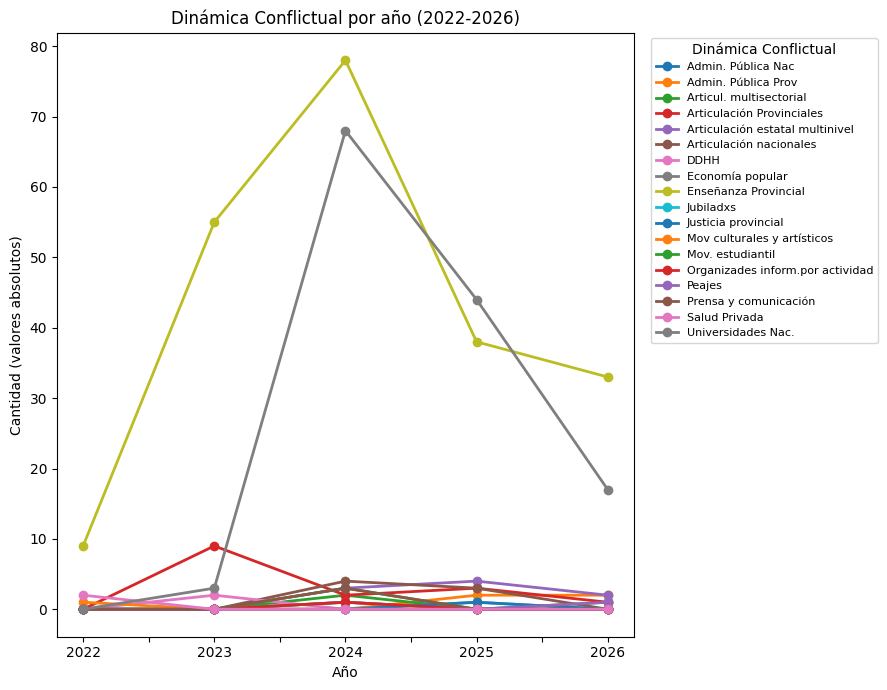

In [ ]:
# ── Ejecutar el menú interactivo ──────────────────────────────────
# Correr esta celda tantas veces como gráficos distintos quieras generar.
resultado_grafico = menu_graficos(df_limpio)

### Notas de uso del motor gráfico

- **Opciones 1-10**: reproducen los gráficos originales del PDF de referencia (formato agregado,
  pertenencia sectorial, demandas, participación, dinámicas conflictuales), ahora con período
  configurable (año/trimestre/mes) y rango de años a elección.
- **Opción 11**: perfil temático apilado al 100%. Para el perfil **por diario** (en vez de por
  período), usar la celda dedicada de la Sección 5.
- **Opciones 12-18**: nuevos análisis (red de co-ocurrencia, diversidad Shannon, organizaciones,
  picos, comparación de períodos, directa vs. indirecta), todos parametrizables por rango de años.
- **Opción 19**: gráfico libre — elegís cualquier columna de la base y el tipo de gráfico.
